In [1]:
import socket; socket.gethostname()

'ins011'

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from classy import Class

from pathlib import Path
import subprocess

### Power Spectra, and Parameter Effects

In [3]:
default_params = {
    # Output
    "output": "tCl,pCl,lCl,mPk",
    "modes": "s",
    "ic": "ad",
    "gauge": "synchronous",

    # Background / cosmology
    "h": 0.67810,
    "YHe": "BBN",
    "recombination": "HyRec",
    "reio_parametrization": "reio_camb",
    #"z_reio": 7.6711,
    "reionization_exponent": 1.5,
    "reionization_width": 0.5,
    "helium_fullreio_redshift": 3.5,
    "helium_fullreio_width": 0.5,

    "varying_fundamental_constants": "none",
    "T_cmb": 2.7255,

    "omega_b": 0.02238280,
    "N_ur": 3.044,
    "omega_cdm": 0.1201075,
    "Omega_k": 0.0,

    # Dark sector
    "Omega_dcdmdr": 0.0,
    "f_idm": 0.0,
    "stat_f_idr": 0.875,
    "Omega_fld": 0.0,
    "Omega_scf": 0.0,

    # DM / PBH effects
    "DM_annihilation_efficiency": 0.0,
    "DM_decay_fraction": 0.0,
    "DM_decay_Gamma": 0.0,

    "PBH_evaporation_fraction": 0.0,
    "PBH_evaporation_mass": 0.0,
    "PBH_accretion_fraction": 0.0,
    "PBH_accretion_mass": 0.0,
    "PBH_accretion_recipe": "disk_accretion",
    "PBH_accretion_ADAF_delta": 1.e-3,
    "PBH_accretion_eigenvalue": 0.1,

    "f_eff_type": "on_the_spot",
    "chi_type": "CK_2004",

    # Primordial spectrum
    "Pk_ini_type": "analytic_Pk",
    "k_pivot": 0.05,
    "A_s": 2.100549e-09,
    "n_s": 0.9660499,
    "alpha_s": 0.0,

    # Precision
    "l_max_scalars": 4000,
    "P_k_max_h/Mpc": 1.0,
    "z_pk": 0,

    # Lensing
    "lensing": "yes",
    "want_lcmb_full_limber": "yes",
    "accurate_lensing": 1,

    # Spectral distortions
    "sd_branching_approx": "exact",
    "sd_PCA_size": 2,
    "sd_detector_name": "PIXIE",
    "sd_only_exotic": "no",
    "sd_include_g_distortion": "no",
    "sd_add_y": 0.0,
    "sd_add_mu": 0.0,

    # SZ
    "include_SZ_effect": "no",

    # Output options
    "overwrite_root": "no",
    "headers": "yes",
    "format": "class",
    "write_background": "no",
    "write_thermodynamics": "no",
    "write_primordial": "no",
    "write_exotic_injection": "no",
    "write_distortions": "no",
    "write_parameters": "yes",
    "write_warnings": "no",

    # Verbosity
    "input_verbose": 1,
    "background_verbose": 1,
    "thermodynamics_verbose": 1,
    "perturbations_verbose": 1,
    "transfer_verbose": 1,
    "primordial_verbose": 1,
    "harmonic_verbose": 1,
    "fourier_verbose": 1,
    "lensing_verbose": 1,
    "distortions_verbose": 1,
    "output_verbose": 1,
}

In [9]:
thomson_rescaling_values = [0.9, 0.95, 1.0, 1.05, 1.1]

# Fixing z_reio
for tr in thomson_rescaling_values:
    tr_name = f"{tr:g}".replace(".", "p") # e.g. 0.95 -> "0p95"

    ini_path = Path(f"Ad{tr_name}_rescale_fixedzreio.ini")
    params = default_params.copy()
    params["root"] = f"../output/Ad{tr_name}_rescale_fixedzreio_"
    params["thomson_rescaling"] = tr
    #params["thomson_rescaling_z"] = 200
    #params["thomson_rescaling_dz"] = 20
    params["z_reio"] = 7.6711

    with open(ini_path, "w") as f:
        for key, value in params.items():
            f.write(f"{key} = {value}\n")
    print(f"Wrote {ini_path}")

    result = subprocess.run(
        ["../class", str(ini_path)],
        capture_output=True,
        text=True
    )
    print(result.stdout)
    if result.returncode != 0:
        print("CLASS ERROR:")
        print(result.stderr)
    else:
        print(f"Finished thomson_rescaling = {tr}, fixed z_reio")

# Fixing tau_reio
for tr in thomson_rescaling_values:
    tr_name = f"{tr:g}".replace(".", "p") # e.g. 0.95 -> "0p95"

    ini_path = Path(f"Ad{tr_name}_rescale_fixedtaureio.ini")
    params = default_params.copy()
    params["root"] = f"../output/Ad{tr_name}_rescale_fixedtaureio_"
    params["thomson_rescaling"] = tr
    #params["thomson_rescaling_z"] = 200
    #params["thomson_rescaling_dz"] = 20
    params["tau_reio"] = 0.0543084

    with open(ini_path, "w") as f:
        for key, value in params.items():
            f.write(f"{key} = {value}\n")
    print(f"Wrote {ini_path}")

    result = subprocess.run(
        ["../class", str(ini_path)],
        capture_output=True,
        text=True
    )
    print(result.stdout)
    if result.returncode != 0:
        print("CLASS ERROR:")
        print(result.stderr)
    else:
        print(f"Finished thomson_rescaling = {tr}, fixed tau_reio")

Wrote Ad0p9_rescale_fixedzreio.ini
Reading input parameters
 -> matched budget equations by adjusting Omega_Lambda = 0.690026
Running CLASS version v3.4.0
Computing background
 -> age = 13.770598 Gyr
 -> conformal age = 14151.897989 Mpc
 -> N_eff = 3.044 (summed over all species that are non-relativistic at early times) 
 -> radiation/matter equality at z = 3405.751108
    corresponding to conformal time = 112.722902 Mpc
Computing thermodynamics using HyRec 2020
 -> with primordial helium mass fraction Y_He = 0.2453
 -> recombination (maximum of visibility function) at z = 1097.064438
    corresponding to conformal time = 279.066941 Mpc
    with comoving sound horizon = 143.792163 Mpc
    angular diameter distance = 12.633895 Mpc
    sound horizon angle 100*theta_s = 1.036502
    Thomson optical depth crosses one at z_* = 1094.113516
    giving an angle 100*theta_* = 1.038380
 -> baryon drag stops at z = 1067.853670
    corresponding to conformal time = 284.733818 Mpc
    with comoving

<>:45: SyntaxWarning: "is" with a literal. Did you mean "=="?
<>:45: SyntaxWarning: "is" with a literal. Did you mean "=="?
/tmp/ipykernel_1907415/4122538371.py:45: SyntaxWarning: "is" with a literal. Did you mean "=="?
  if fixtype is "_fixedzreio":


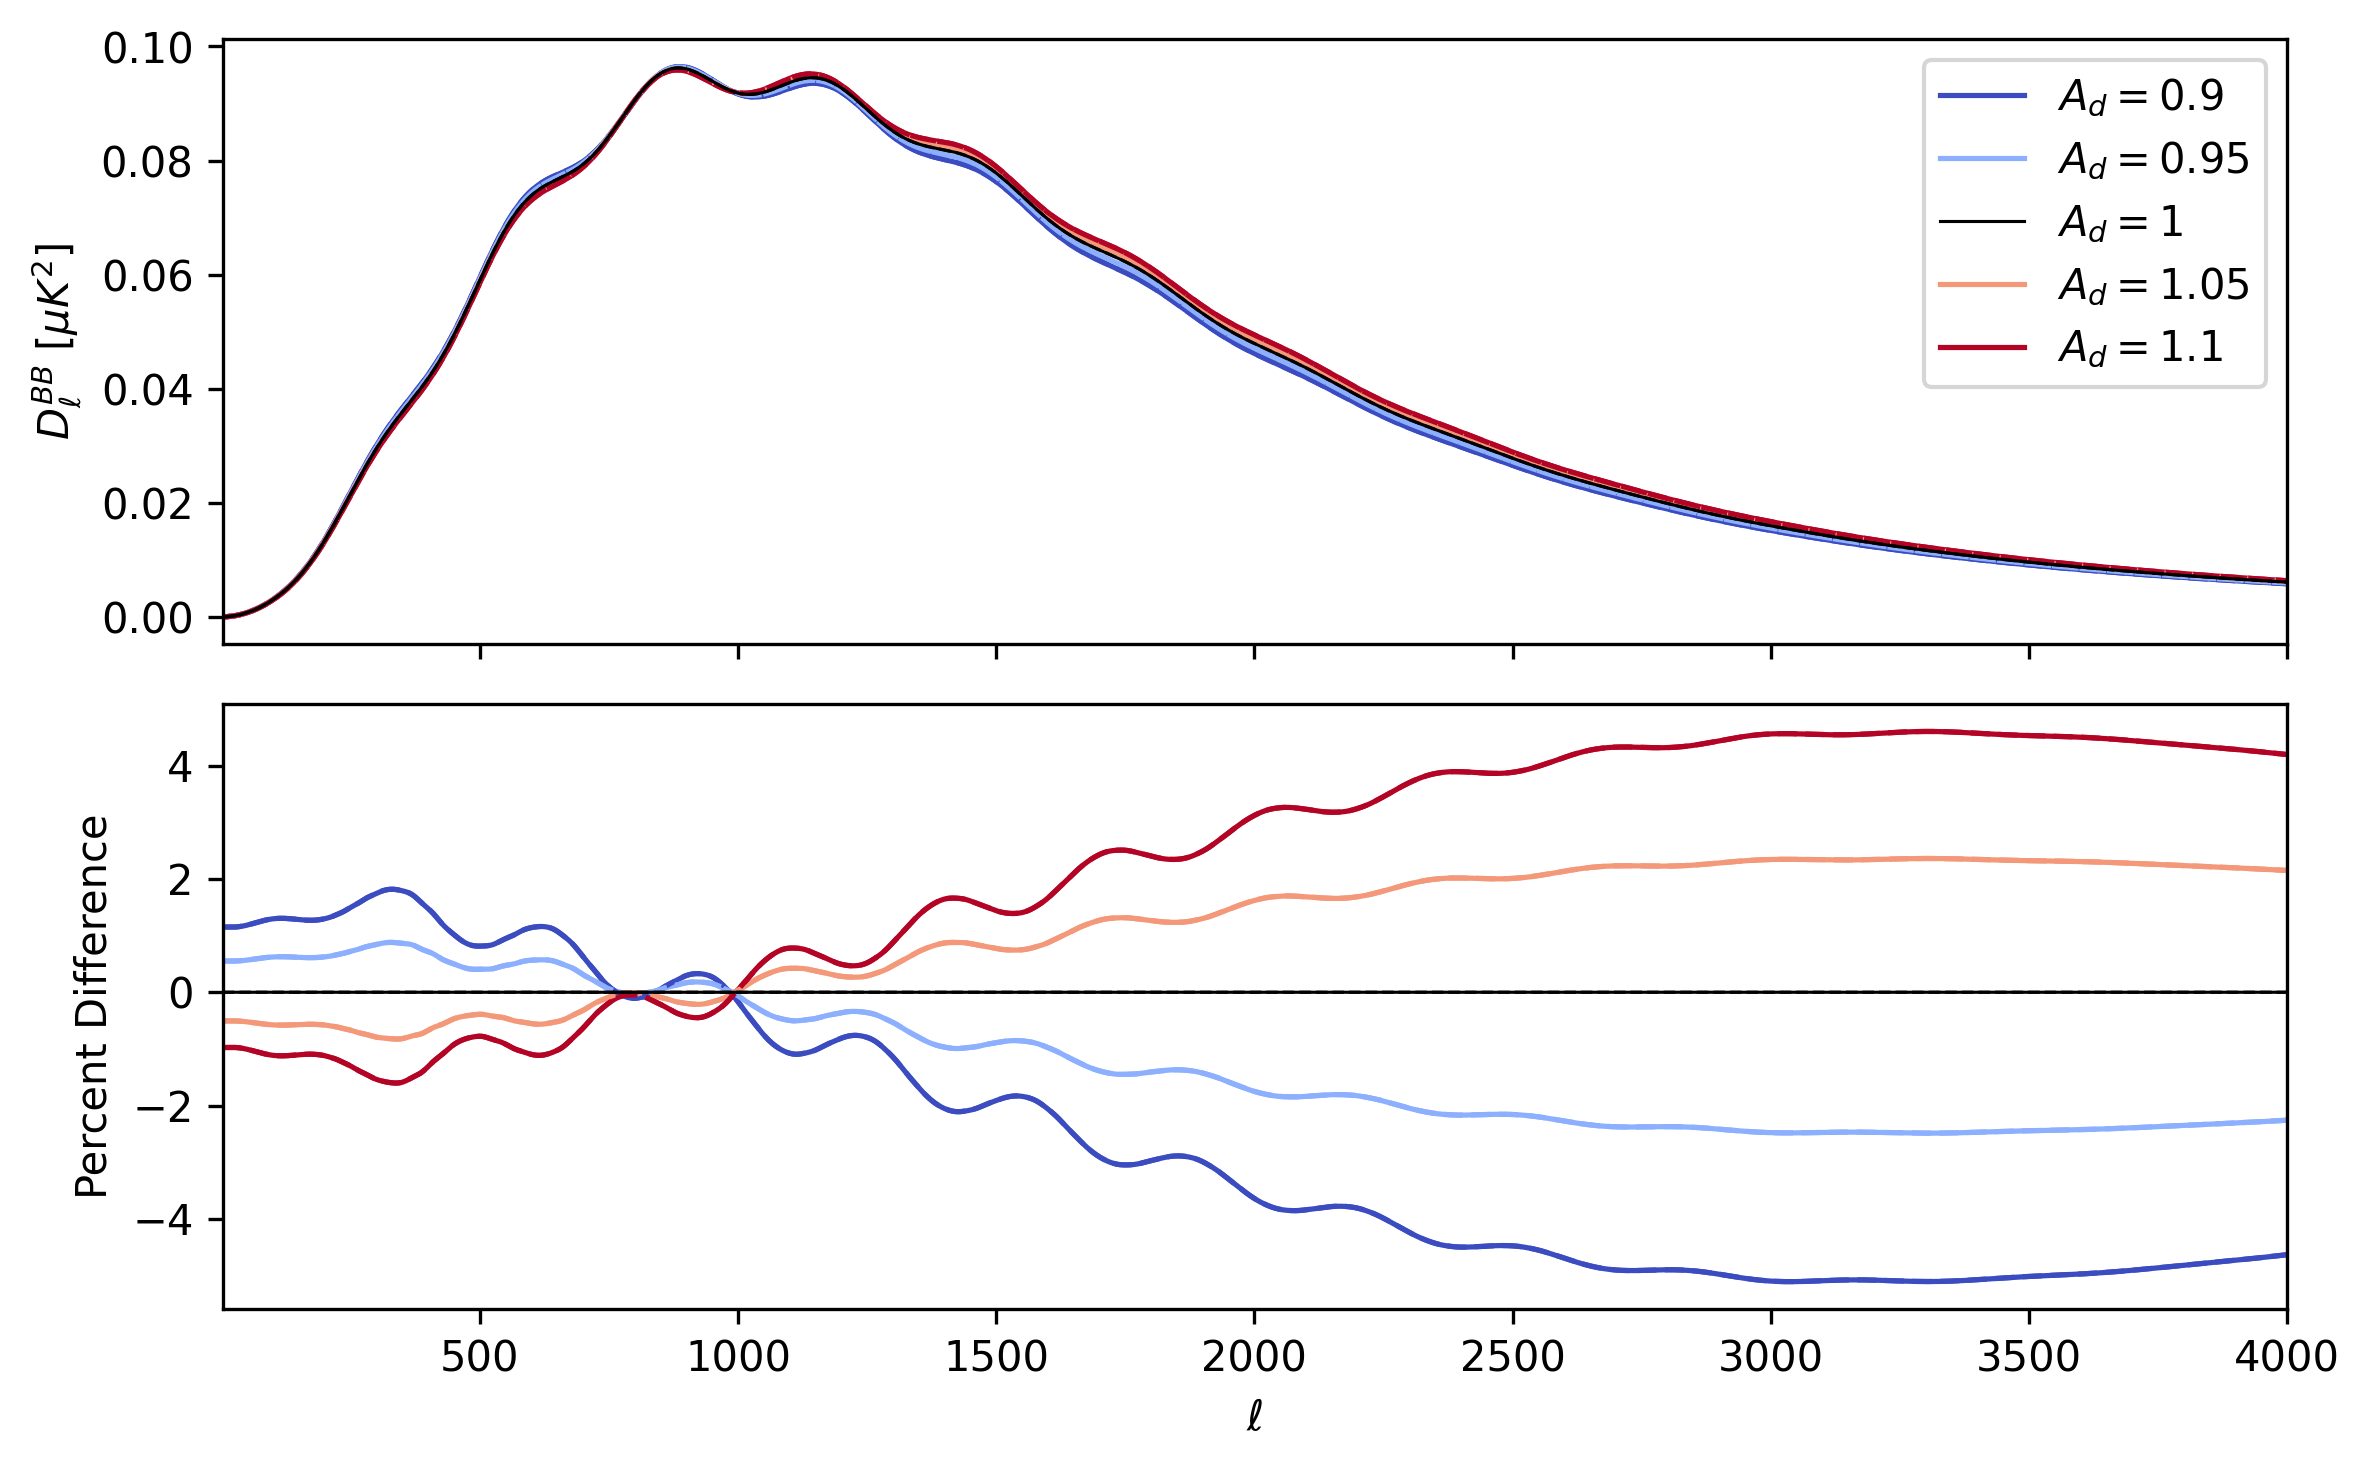

In [21]:
# 00 : z_t = 200, deltaz = 20
# 01 : z_t = 400, deltaz = 20
# 02 : z_t = 100, deltaz = 20
# 03 : z_t = 200, deltaz = 40
# 04 : z_t = 200, deltaz = 10
thomson_rescaling_values = [0.9, 0.95, 1.0, 1.05, 1.1]
cmap = plt.cm.coolwarm
norm = TwoSlopeNorm(vmin=min(thomson_rescaling_values),vcenter=1.0,vmax=max(thomson_rescaling_values))
quantity_to_plot = "BB"
quantity_to_plot_indexes = {
    "TT": 1, "EE": 2, "TE": 3, "BB": 4
} 
T_cmb = 2.7255
factor = T_cmb**2 * 1e12

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 5), dpi=300, sharex=True)

# A_d = 1.0
tr = 1.0
tr_name = f"{tr:g}".replace(".", "p")
filename = f"../output/Ad{tr_name}_rescale_fixedtaureio_00_cl_lensed.dat"
data = np.loadtxt(filename)
ell_baseline = data[:, 0]
TT_baseline = data[:, quantity_to_plot_indexes[quantity_to_plot]] * factor

# non-unity A_d
for fixtype, linestyle in zip(["_fixedzreio", "_fixedtaureio"], ["-", "--"]):
#for fixtype, linestyle in zip(["_fixedzreio"], ["-"]):
    for tr in thomson_rescaling_values:
        tr_name = f"{tr:g}".replace(".", "p")
        filename = f"../output/Ad{tr_name}_rescale{fixtype}_00_cl_lensed.dat"
        data = np.loadtxt(filename)
        ell = data[:, 0]
        TT = data[:, quantity_to_plot_indexes[quantity_to_plot]] * factor
    
        if np.isclose(tr, 1.0):
            color = "black"
            linewidth = 0.75
            zorder = 10
        else:
            color = cmap(norm(tr))
            linewidth = 1.25
            zorder = 1

        if fixtype is "_fixedzreio":
            ax1.plot(ell,TT,
                     color=color,linewidth=linewidth,label=fr"$A_d={tr:g}$",zorder=zorder,linestyle=linestyle)
            ax2.plot(ell,100*(TT-TT_baseline)/TT_baseline,
                     color=color,linewidth=linewidth,label=fr"$A_d={tr:g}$",zorder=zorder,linestyle=linestyle)
        else:
            ax1.plot(ell,TT,
                     color=color,linewidth=linewidth,zorder=zorder,linestyle=linestyle)
            ax2.plot(ell,100*(TT-TT_baseline)/TT_baseline,
                     color=color,linewidth=linewidth,zorder=zorder,linestyle=linestyle)

ax1.set_ylabel(
    rf"$D_\ell^{{{quantity_to_plot}}}\ [\mu K^2]$"
)
ax2.set_ylabel(
    r"Percent Difference"
)

ax2.set_xlabel(r"$\ell$")
ax2.set_xlim(2, 4000)
#ax2.set_ylim(-30,30)
#ax2.set_ylim(-50,50)

ax1.legend(loc='upper right')
plt.tight_layout()
#ax1.set_title(r"$\dot{\kappa}\to A_d\dot{\kappa}$")
plt.show()

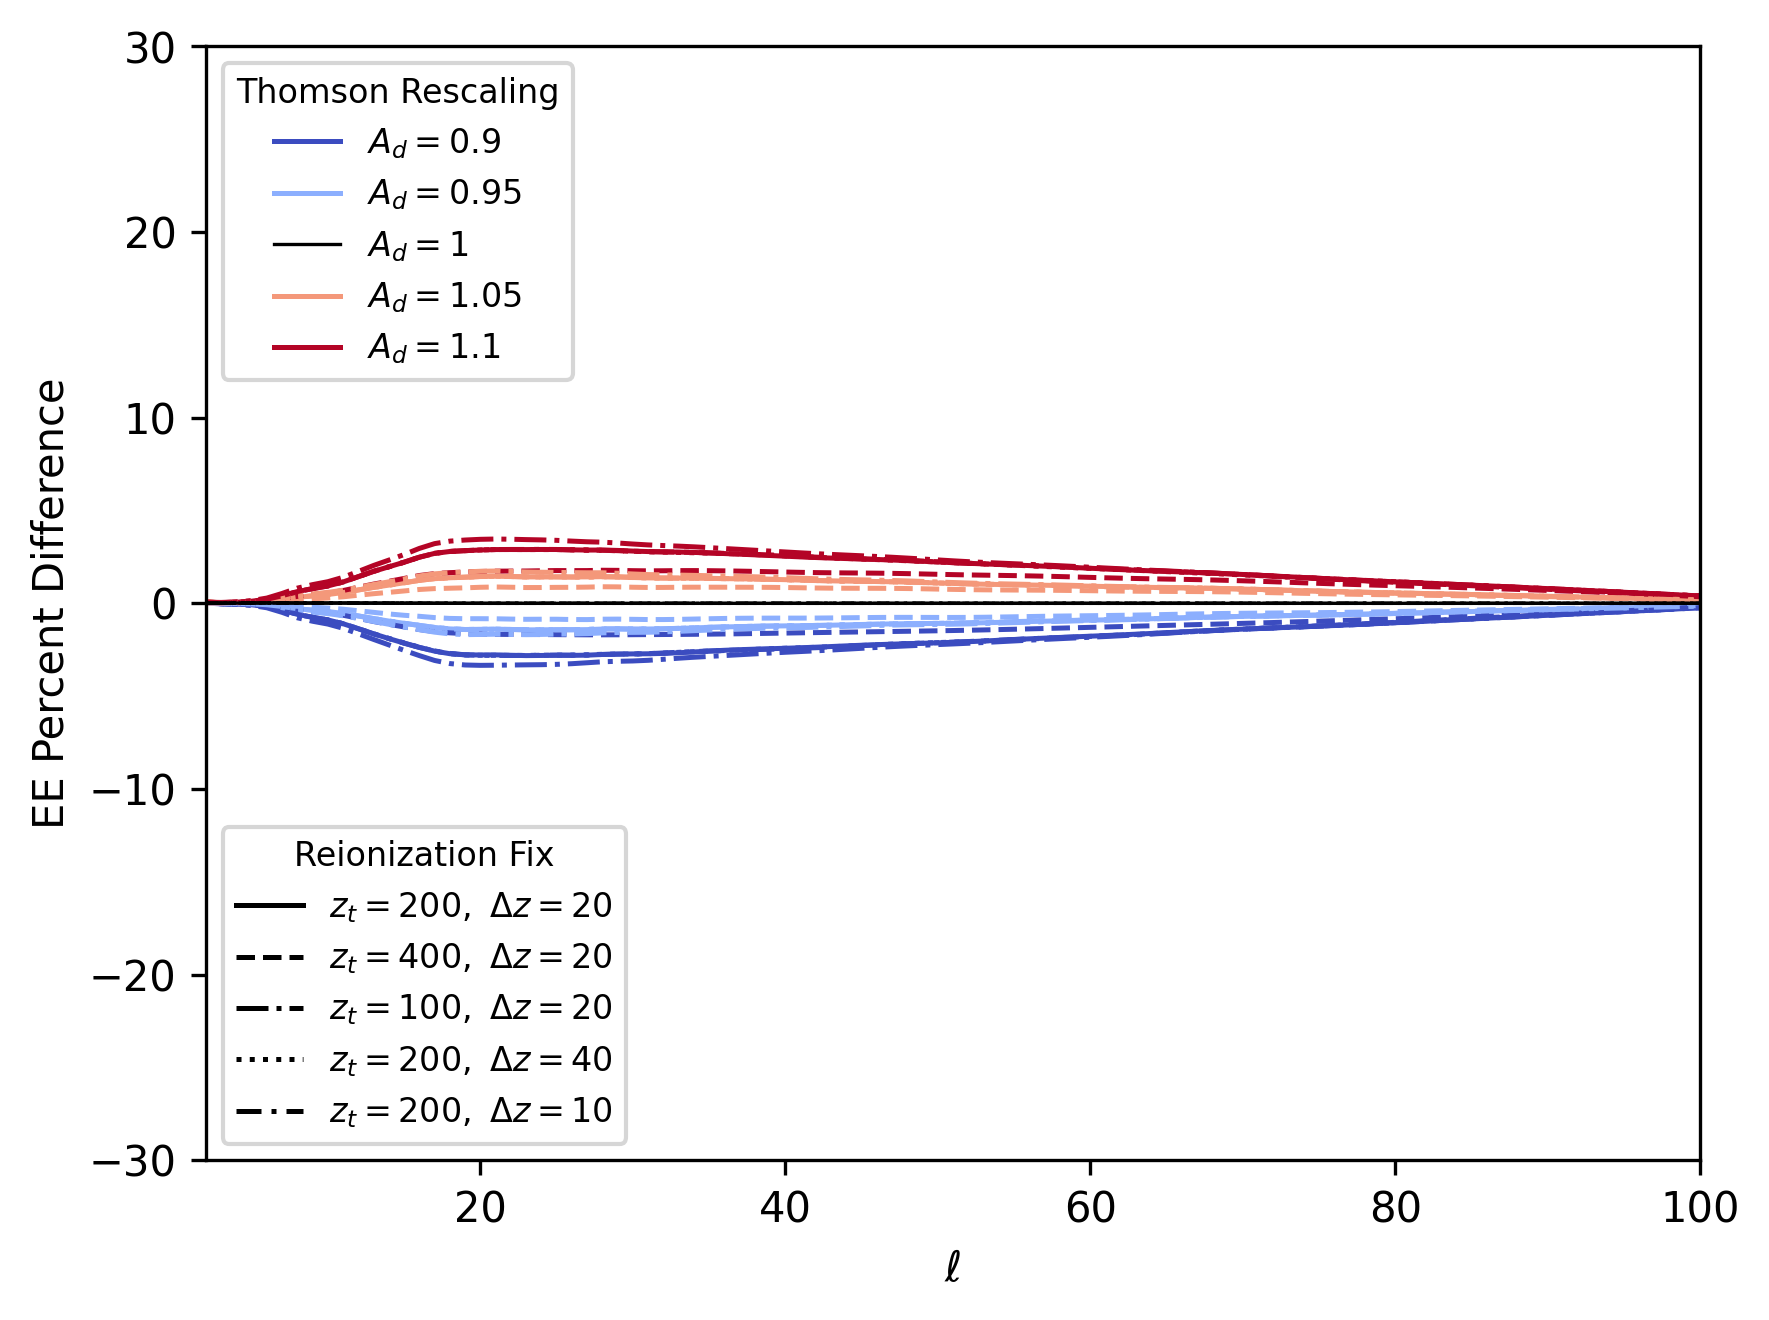

In [34]:
run_keys = {
    (200, 20): "00",
    (400, 20): "01",
    (100, 20): "02",
    (200, 40): "03",
    (200, 10): "04"
}

thomson_rescaling_values = [0.9, 0.95, 1.0, 1.05, 1.1]

cmap = plt.cm.coolwarm
norm = TwoSlopeNorm(
    vmin=min(thomson_rescaling_values),
    vcenter=1.0,
    vmax=max(thomson_rescaling_values)
)

quantity_to_plot = "EE"

quantity_to_plot_indexes = {
    "TT": 1,
    "EE": 2,
    "TE": 3,
    "BB": 4
}

T_cmb = 2.7255
factor = T_cmb**2 * 1e12


# ============================================================
# Line styles for the five runs
# ============================================================
run_linestyles = {
    (200, 20): "-",
    (400, 20): "--",
    (100, 20): "-.",
    (200, 40): ":",
    (200, 10): (0, (5, 2, 1, 2))
}


# ============================================================
# Figure
# ============================================================
fig, ax = plt.subplots(
    figsize=(6, 4.5),
    dpi=300
)


# ============================================================
# Plot all runs
# ============================================================
for (z_t, delta_z), run_key in run_keys.items():

    linestyle = run_linestyles[(z_t, delta_z)]

    # --------------------------------------------------------
    # A_d = 1 baseline
    # --------------------------------------------------------
    tr = 1.0
    tr_name = f"{tr:g}".replace(".", "p")

    filename = (
        f"../output/Ad{tr_name}_rescale_fixedtaureio_"
        f"{run_key}_cl_lensed.dat"
    )

    data = np.loadtxt(filename)

    ell_baseline = data[:, 0]

    baseline = (
        data[:, quantity_to_plot_indexes[quantity_to_plot]]
        * factor
    )


    # --------------------------------------------------------
    # Only _fixedzreio
    # --------------------------------------------------------
    for tr in thomson_rescaling_values:

        tr_name = f"{tr:g}".replace(".", "p")

        filename = (
            f"../output/Ad{tr_name}_rescale_fixedzreio_"
            f"{run_key}_cl_lensed.dat"
        )

        data = np.loadtxt(filename)

        ell = data[:, 0]

        spectrum = (
            data[:, quantity_to_plot_indexes[quantity_to_plot]]
            * factor
        )

        percent_difference = (
            100 * (spectrum - baseline) / baseline
        )


        # ----------------------------------------------------
        # Color = A_d
        # ----------------------------------------------------
        if np.isclose(tr, 1.0):
            color = "black"
            linewidth = 0.8
            zorder = 10
        else:
            color = cmap(norm(tr))
            linewidth = 1.2
            zorder = 1


        ax.plot(
            ell,
            percent_difference,
            color=color,
            linewidth=linewidth,
            linestyle=linestyle,
            zorder=zorder
        )


# ============================================================
# Axes
# ============================================================
ax.set_xlabel(r"$\ell$")
ax.set_ylabel(rf"{quantity_to_plot} Percent Difference")

ax.axhline(
    0,
    color="black",
    linewidth=0.5,
    linestyle=":"
)


# ============================================================
# Legend 1: A_d colors
# ============================================================
ad_handles = []

for tr in thomson_rescaling_values:

    if np.isclose(tr, 1.0):
        color = "black"
        linewidth = 0.8
    else:
        color = cmap(norm(tr))
        linewidth = 1.2

    handle, = ax.plot(
        [],
        [],
        color=color,
        linewidth=linewidth,
        linestyle="-",
        label=fr"$A_d={tr:g}$"
    )

    ad_handles.append(handle)


legend_ad = ax.legend(
    handles=ad_handles,
    title=r"Thomson Rescaling",
    loc="upper left",
    fontsize=8,
    title_fontsize=8
)

ax.add_artist(legend_ad)


# ============================================================
# Legend 2: run line styles
# ============================================================
run_handles = []

for (z_t, delta_z), run_key in run_keys.items():

    handle, = ax.plot(
        [],
        [],
        color="black",
        linewidth=1.2,
        linestyle=run_linestyles[(z_t, delta_z)],
        label=fr"$z_t={z_t},\ \Delta z={delta_z}$"
    )

    run_handles.append(handle)


ax.legend(
    handles=run_handles,
    title="Reionization Fix",
    loc="lower left",
    fontsize=8,
    title_fontsize=8
)
ax.set_ylim(-30,30)
ax.set_xlim(2, 100)

plt.tight_layout()
plt.show()

In [6]:
phenomenological_damping_tail_values = [0, 5000, 7500, 10000, 12500, 15000]

for tr in phenomenological_damping_tail_values:
    tr_name = f"{tr:g}".replace(".", "p") # e.g. 0.95 -> "0p95"

    ini_path = Path(f"elld{tr_name}_rescale.ini")
    params = default_params.copy()
    params["root"] = f"../output/elld{tr_name}_rescale_"
    params["phenomenological_damping_tail"] = tr

    with open(ini_path, "w") as f:
        for key, value in params.items():
            f.write(f"{key} = {value}\n")
    print(f"Wrote {ini_path}")

    result = subprocess.run(
        ["../class", str(ini_path)],
        capture_output=True,
        text=True
    )
    print(result.stdout)
    if result.returncode != 0:
        print("CLASS ERROR:")
        print(result.stderr)
    else:
        print(f"Finished phenomenological_damping_tail = {tr}")

Wrote elld0_rescale.ini
Reading input parameters
 -> matched budget equations by adjusting Omega_Lambda = 0.690026
Running CLASS version v3.4.0
Computing background
 -> age = 13.770598 Gyr
 -> conformal age = 14151.897989 Mpc
 -> N_eff = 3.044 (summed over all species that are non-relativistic at early times) 
 -> radiation/matter equality at z = 3405.751108
    corresponding to conformal time = 112.722902 Mpc
Computing thermodynamics using HyRec 2020
 -> with primordial helium mass fraction Y_He = 0.2453
 -> recombination (maximum of visibility function) at z = 1088.772283
    corresponding to conformal time = 280.650572 Mpc
    with comoving sound horizon = 144.510391 Mpc
    angular diameter distance = 12.728574 Mpc
    sound horizon angle 100*theta_s = 1.041798
    Thomson optical depth crosses one at z_* = 1085.125754
    giving an angle 100*theta_* = 1.044146
 -> baryon drag stops at z = 1059.919234
    corresponding to conformal time = 286.316633 Mpc
    with comoving sound hori

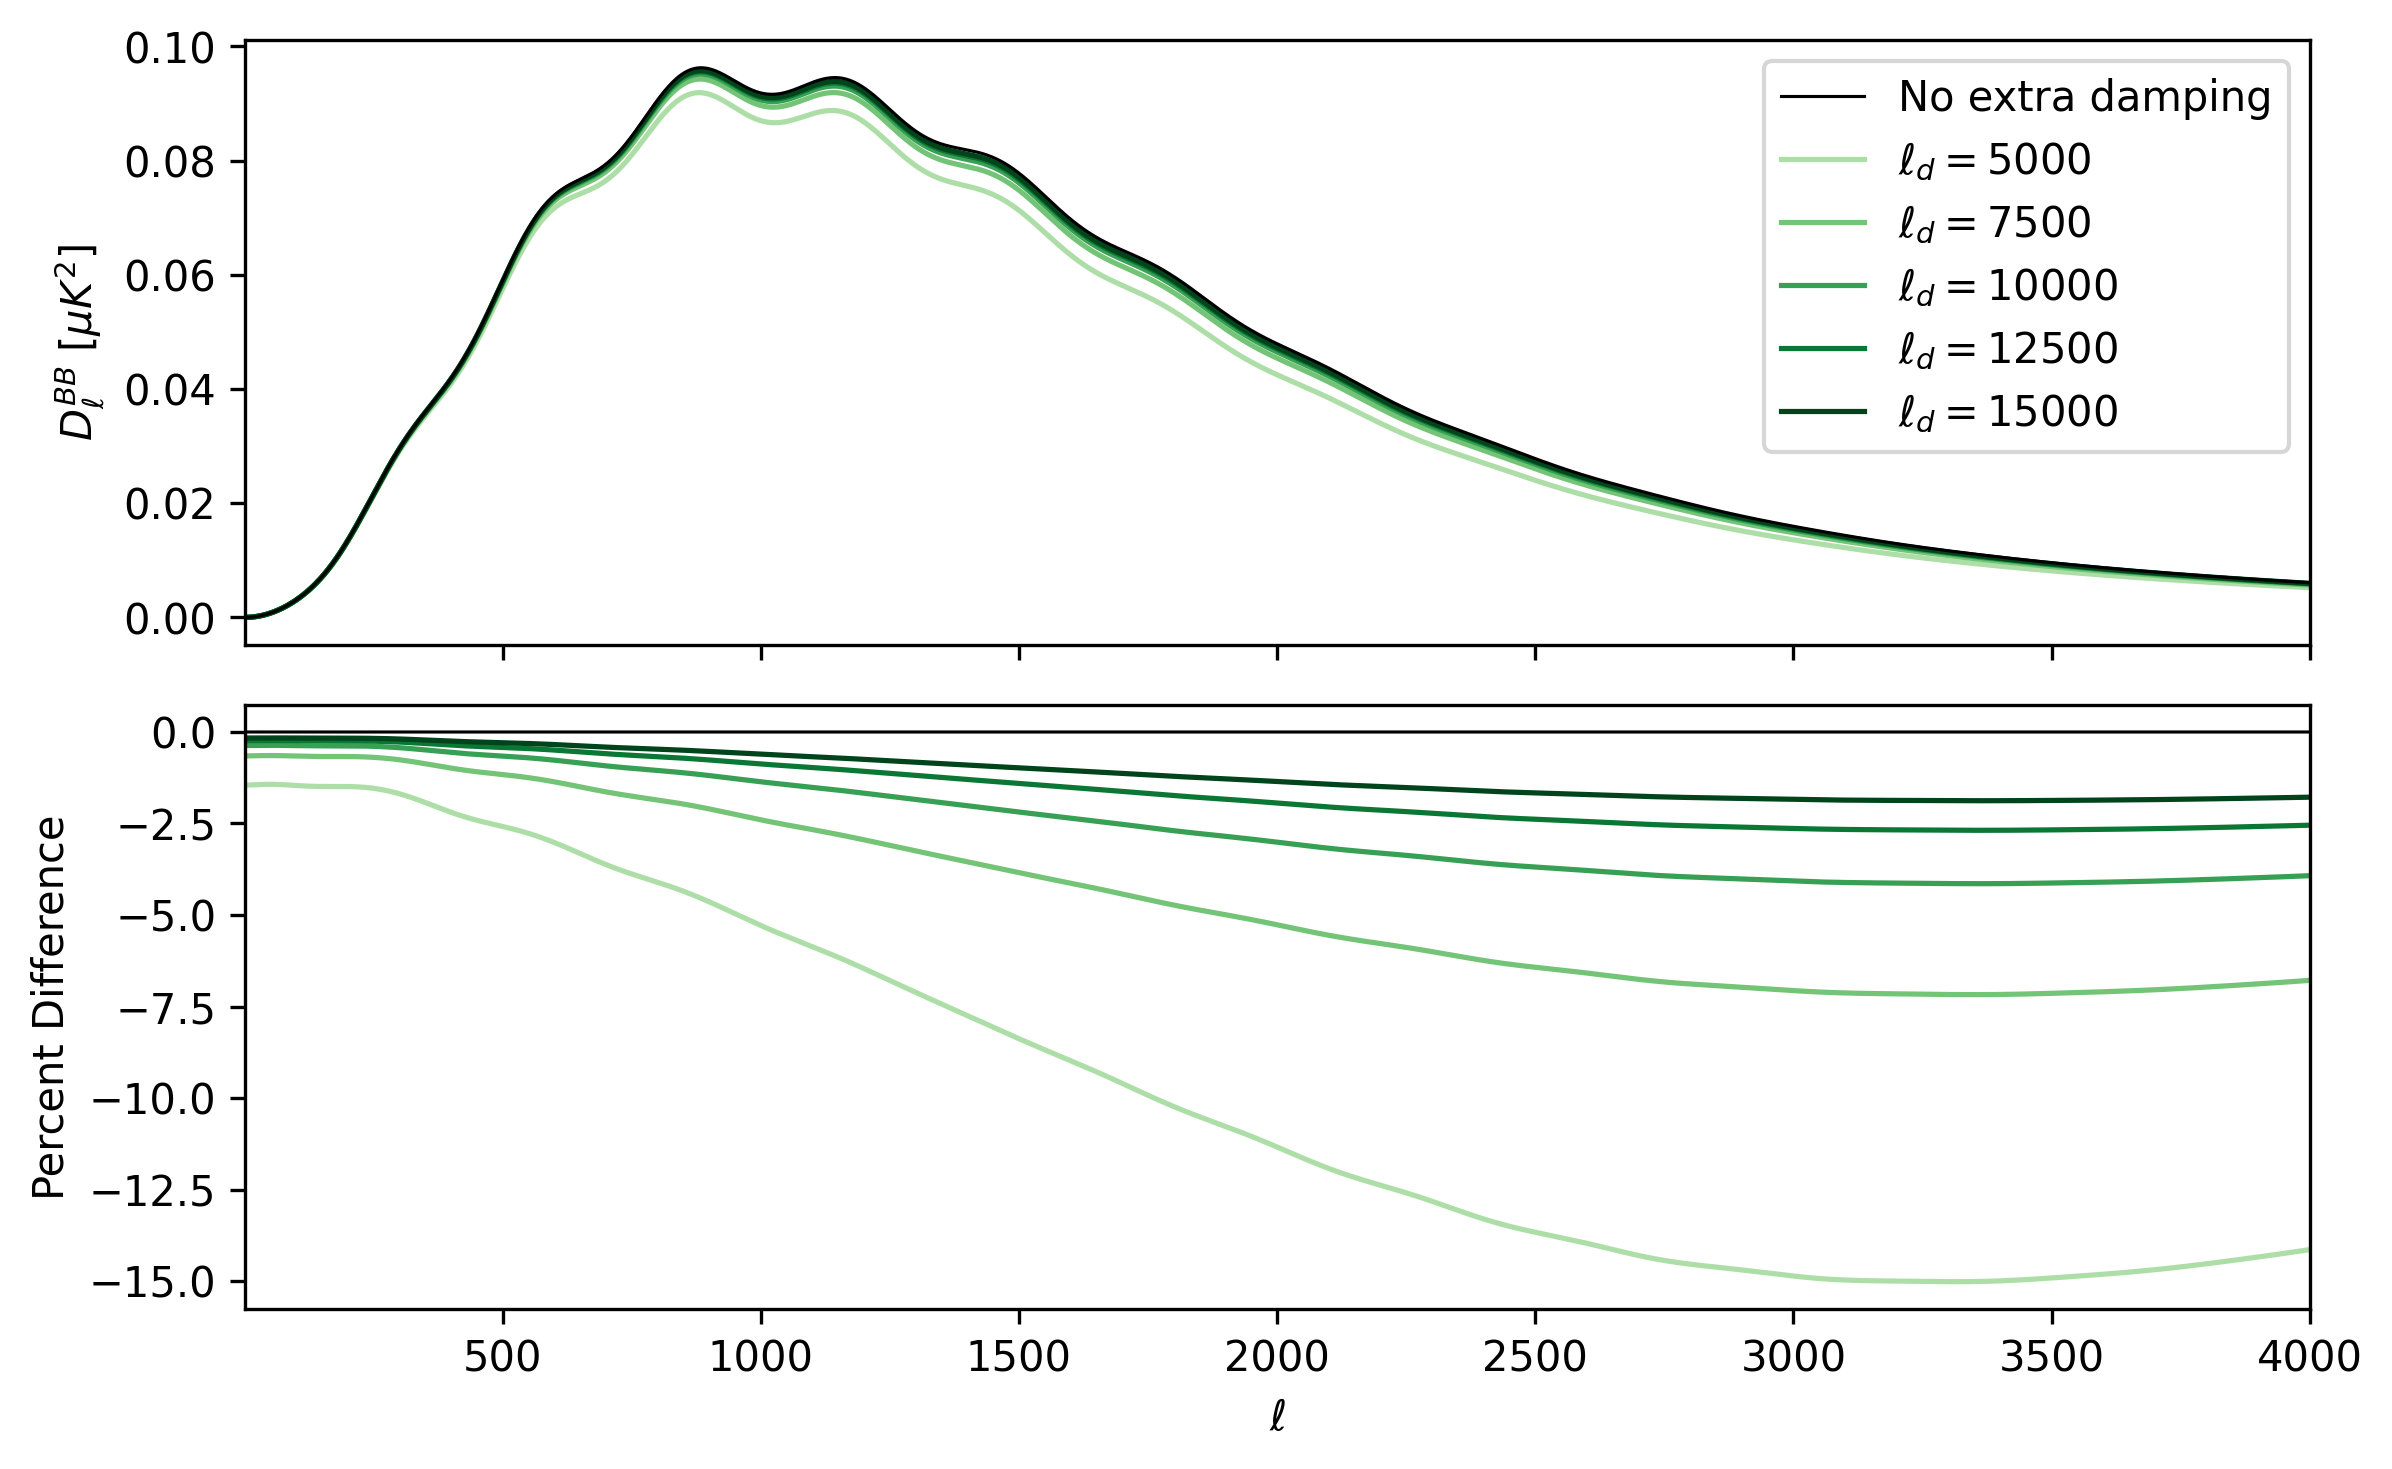

In [7]:
cmap = plt.cm.Greens
norm = plt.Normalize(vmin=min(phenomenological_damping_tail_values),vmax=max(phenomenological_damping_tail_values))
quantity_to_plot = "BB"
quantity_to_plot_indexes = {
    "TT": 1, "EE": 2, "TE": 3, "BB": 4
} 
T_cmb = 2.7255
factor = T_cmb**2 * 1e12

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 5), dpi=300, sharex=True)

# A_d = 1.0
tr = 0
tr_name = f"{tr:g}".replace(".", "p")
filename = f"../output/elld{tr_name}_rescale_00_cl_lensed.dat"
data = np.loadtxt(filename)
ell_baseline = data[:, 0]
TT_baseline = data[:, quantity_to_plot_indexes[quantity_to_plot]] * factor

# non-unity A_d
for tr in phenomenological_damping_tail_values:
    tr_name = f"{tr:g}".replace(".", "p")
    filename = f"../output/elld{tr_name}_rescale_00_cl_lensed.dat"
    data = np.loadtxt(filename)
    ell = data[:, 0]
    TT = data[:, quantity_to_plot_indexes[quantity_to_plot]] * factor

    if np.isclose(tr, 0):
        color = "black"
        linewidth = 0.75
        zorder = 10

        ax1.plot(ell,TT,
                 color=color,linewidth=linewidth,label=fr"No extra damping",zorder=zorder)
        ax2.plot(ell,100*(TT-TT_baseline)/TT_baseline,
                 color=color,linewidth=linewidth,label=fr"No extra damping",zorder=zorder)
    else:
        color = cmap(norm(tr))
        linewidth = 1.25
        zorder = 1
        
        ax1.plot(ell,TT,
                 color=color,linewidth=linewidth,label=fr"$\ell_d={tr:g}$",zorder=zorder)
        ax2.plot(ell,100*(TT-TT_baseline)/TT_baseline,
                 color=color,linewidth=linewidth,label=fr"$\ell_d={tr:g}$",zorder=zorder)

ax1.set_ylabel(
    rf"$D_\ell^{{{quantity_to_plot}}}\ [\mu K^2]$"
)
ax2.set_ylabel(
    r"Percent Difference"
)

ax2.set_xlabel(r"$\ell$")
ax2.set_xlim(2, 4000)
#ax2.set_ylim(-45,5)

ax1.legend(loc='upper right')
plt.tight_layout()
#ax1.set_title(r"$C_\ell^\text{unl} \to C_\ell^\text{unl} e^{-(\ell/\ell_d)^2}$")
plt.show()

### 1D Parameter Scans

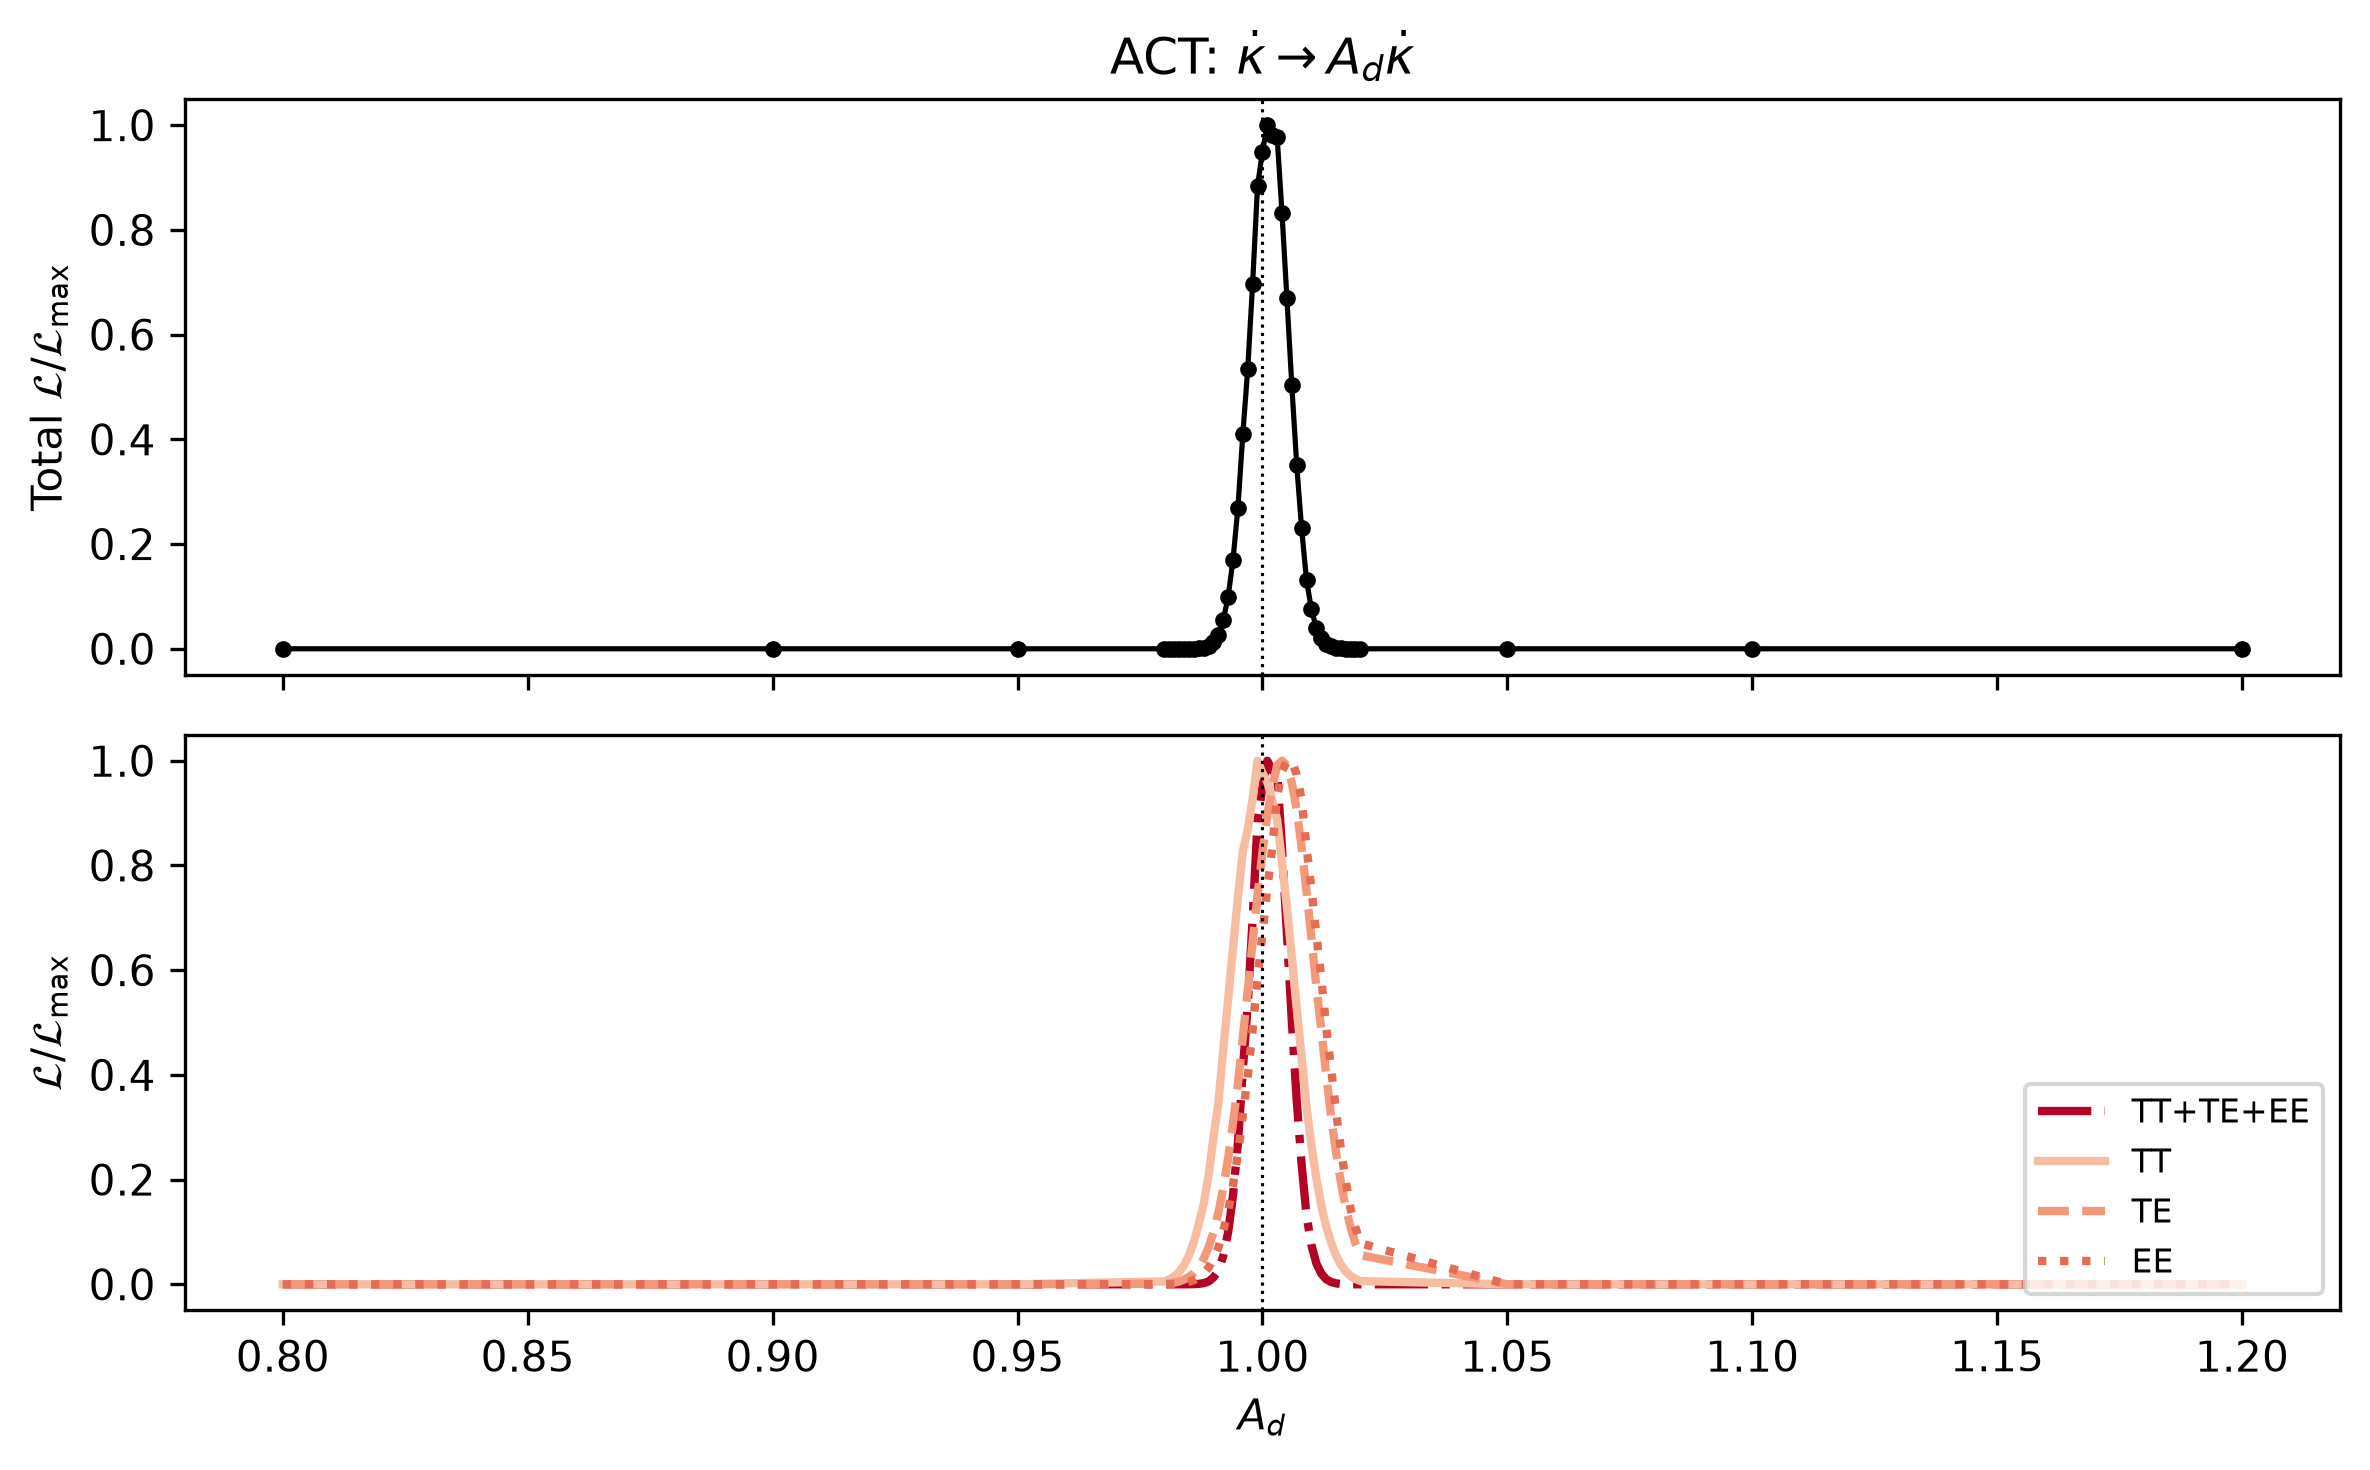

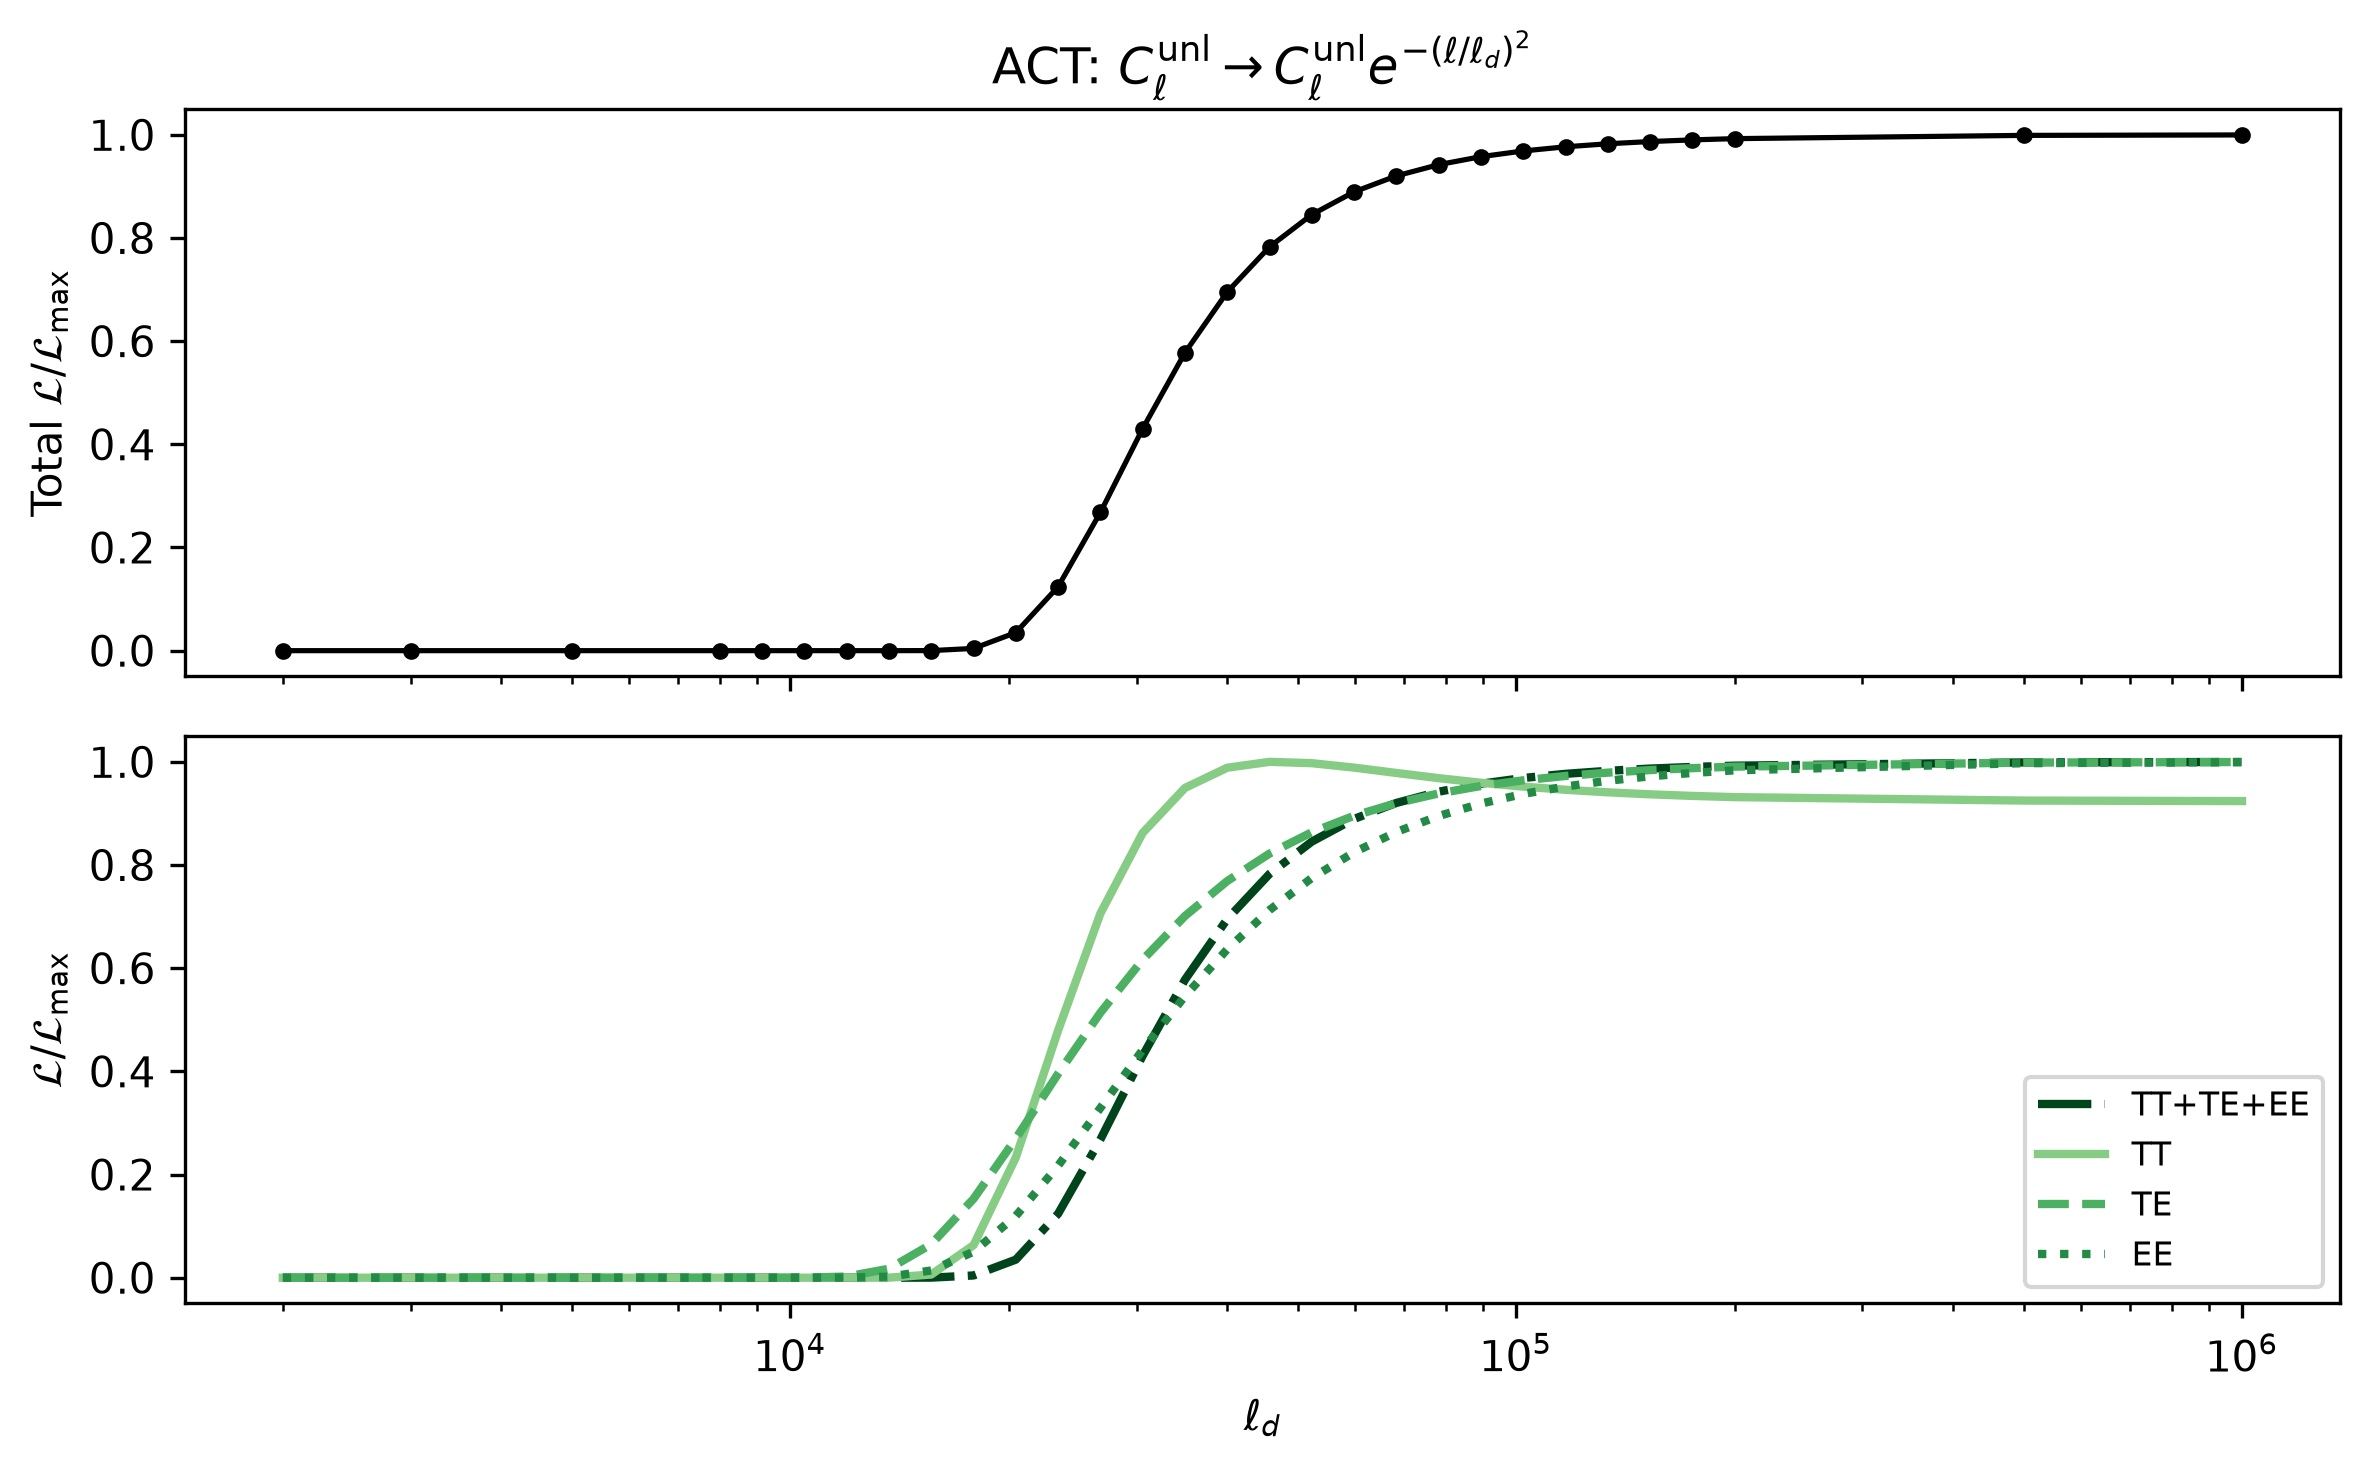

In [10]:
# --- chi2 or relative likelihood vs A_d and l_d, per likelihood ----------------
scan_dir = Path(".")   # folder containing the scan files
mode = "L"             # "L" = relative likelihood L/L_max,  "chi2" = Delta chi2
obs = "ACT"         # "Planck" or "ACT"

# Per experiment: file prefix, and one (label, linestyle, alpha, linewidth) per
# likelihood column in the file, in the same order as the columns after chi2_total.
full_experiments = {
    "Planck": {
        "prefix": "Planck",
        "likelihoods": [
            (r"Low-$\ell$ TT",         "-",  0.75, 0.5),
            (r"Low-$\ell$ EE",         "--", 0.75, 0.5),
            (r"High-$\ell$ TT+TE+EE",  "-.", 1.0,  2.0),
            (r"Lensing",               ":",  1.0,  1.0),
            (r"High-$\ell$ TT",        ":",  1.0,  2.0),
            (r"High-$\ell$ TE",        ":",  1.0,  2.0),
            (r"High-$\ell$ EE",        ":",  1.0,  2.0),
        ],
        "cpos_A_d":  [0.0, 0.25, 1.0, 1.0, 0.65, 0.75, 0.85],
        "cpos_ell_d": [0.2, 0.4,  1.0, 1.0, 0.45, 0.6,  0.75],
    },
    "ACT": {
        "prefix": "ACT",
        "total_label": (r"TT+TE+EE", "-.", 1.0, 2.0),   # the chi2_total column, drawn in the bottom panel
        "likelihoods": [
            (r"TT", "-", 1.0, 2.0),
            (r"TE", "--", 1.0, 2.0),
            (r"EE", ":", 1.0, 2.0),
        ],
        "cpos_A_d":  [1.0, 0.65, 0.75, 0.85],   # first entry is for TT+TE+EE
        "cpos_ell_d": [1.0, 0.45, 0.6,  0.75],
    },
}
experiments = {obs: full_experiments[obs]}

def load_scan(fname):
    data = np.loadtxt(scan_dir / fname)
    data = data[np.argsort(data[:, 0])]
    chi2 = data[:, 1:]
    dchi2 = chi2 - chi2.min(axis=0)          # Delta chi2 w.r.t. best grid point, per column
    y = np.exp(-0.5 * dchi2) if mode == "L" else dchi2
    return data[:, 0], y[:, 0], y[:, 1:]

for exp_name, exp in experiments.items():
    scans = [
        # file suffix,    LCDM value, colormap,        x label,     log x?, colormap positions
        ("_scan_A_d.txt",   1.0, plt.cm.coolwarm, r"$A_d$",    False, exp["cpos_A_d"]),
        ("_scan_ell_d.txt", 0.0, plt.cm.Greens,   r"$\ell_d$", True,  exp["cpos_ell_d"]),
    ]

    for suffix, lcdm_value, cmap, xlabel, logx, cpos in scans:
        x, y_tot, y_like = load_scan(exp["prefix"] + suffix)
        if logx:                        # l_d = 0 means "off" (LCDM); can't go on a log axis
            keep = x > 0
            x, y_tot, y_like = x[keep], y_tot[keep], y_like[keep]

        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 5), dpi=300, sharex=True)

        # Top: total
        ax1.plot(x, y_tot, color="black", linewidth=1.25, marker="o", markersize=3)
        # Bottom: combined (if this experiment's total is a single likelihood), then each likelihood
        if "total_label" in exp:
            lab, ls, a, w = exp["total_label"]
            ax2.plot(x, y_tot, color=cmap(cpos[0]), linewidth=w, linestyle=ls, alpha=a, label=lab)
            cpos_like = cpos[1:]
        else:
            cpos_like = cpos
        for j, ((lab, ls, a, w), c) in enumerate(zip(exp["likelihoods"], cpos_like)):
            ax2.plot(x, y_like[:, j], color=cmap(c), linewidth=w, linestyle=ls, alpha=a,
                     label=lab)

        if mode == "L":
            ax1.set_ylabel(r"Total $\mathcal{L}/\mathcal{L}_{\rm max}$")
            ax2.set_ylabel(r"$\mathcal{L}/\mathcal{L}_{\rm max}$")
            for ax in (ax1, ax2):
                ax.set_ylim(-0.05, 1.05)
        else:
            ax1.set_ylabel(r"Total $\Delta\chi^2$")
            ax2.set_ylabel(r"$\Delta\chi^2$")
            for ax in (ax1, ax2):
                ax.set_ylim(-5, 50)

        ax2.set_xlabel(xlabel)
        if logx:
            ax2.set_xscale("log")
            ax1.set_title(exp_name + r": $C_\ell^\text{unl} \to C_\ell^\text{unl} e^{-(\ell/\ell_d)^2}$")
        else:
            for ax in (ax1, ax2):
                ax.axvline(lcdm_value, color="black", linewidth=0.75, linestyle=":")
            ax1.set_title(exp_name + r": $\dot{\kappa}\to A_d\dot{\kappa}$")

        ax2.legend(loc="lower right" if mode == "L" else "upper center", fontsize=8)
        plt.tight_layout()
        plt.show()

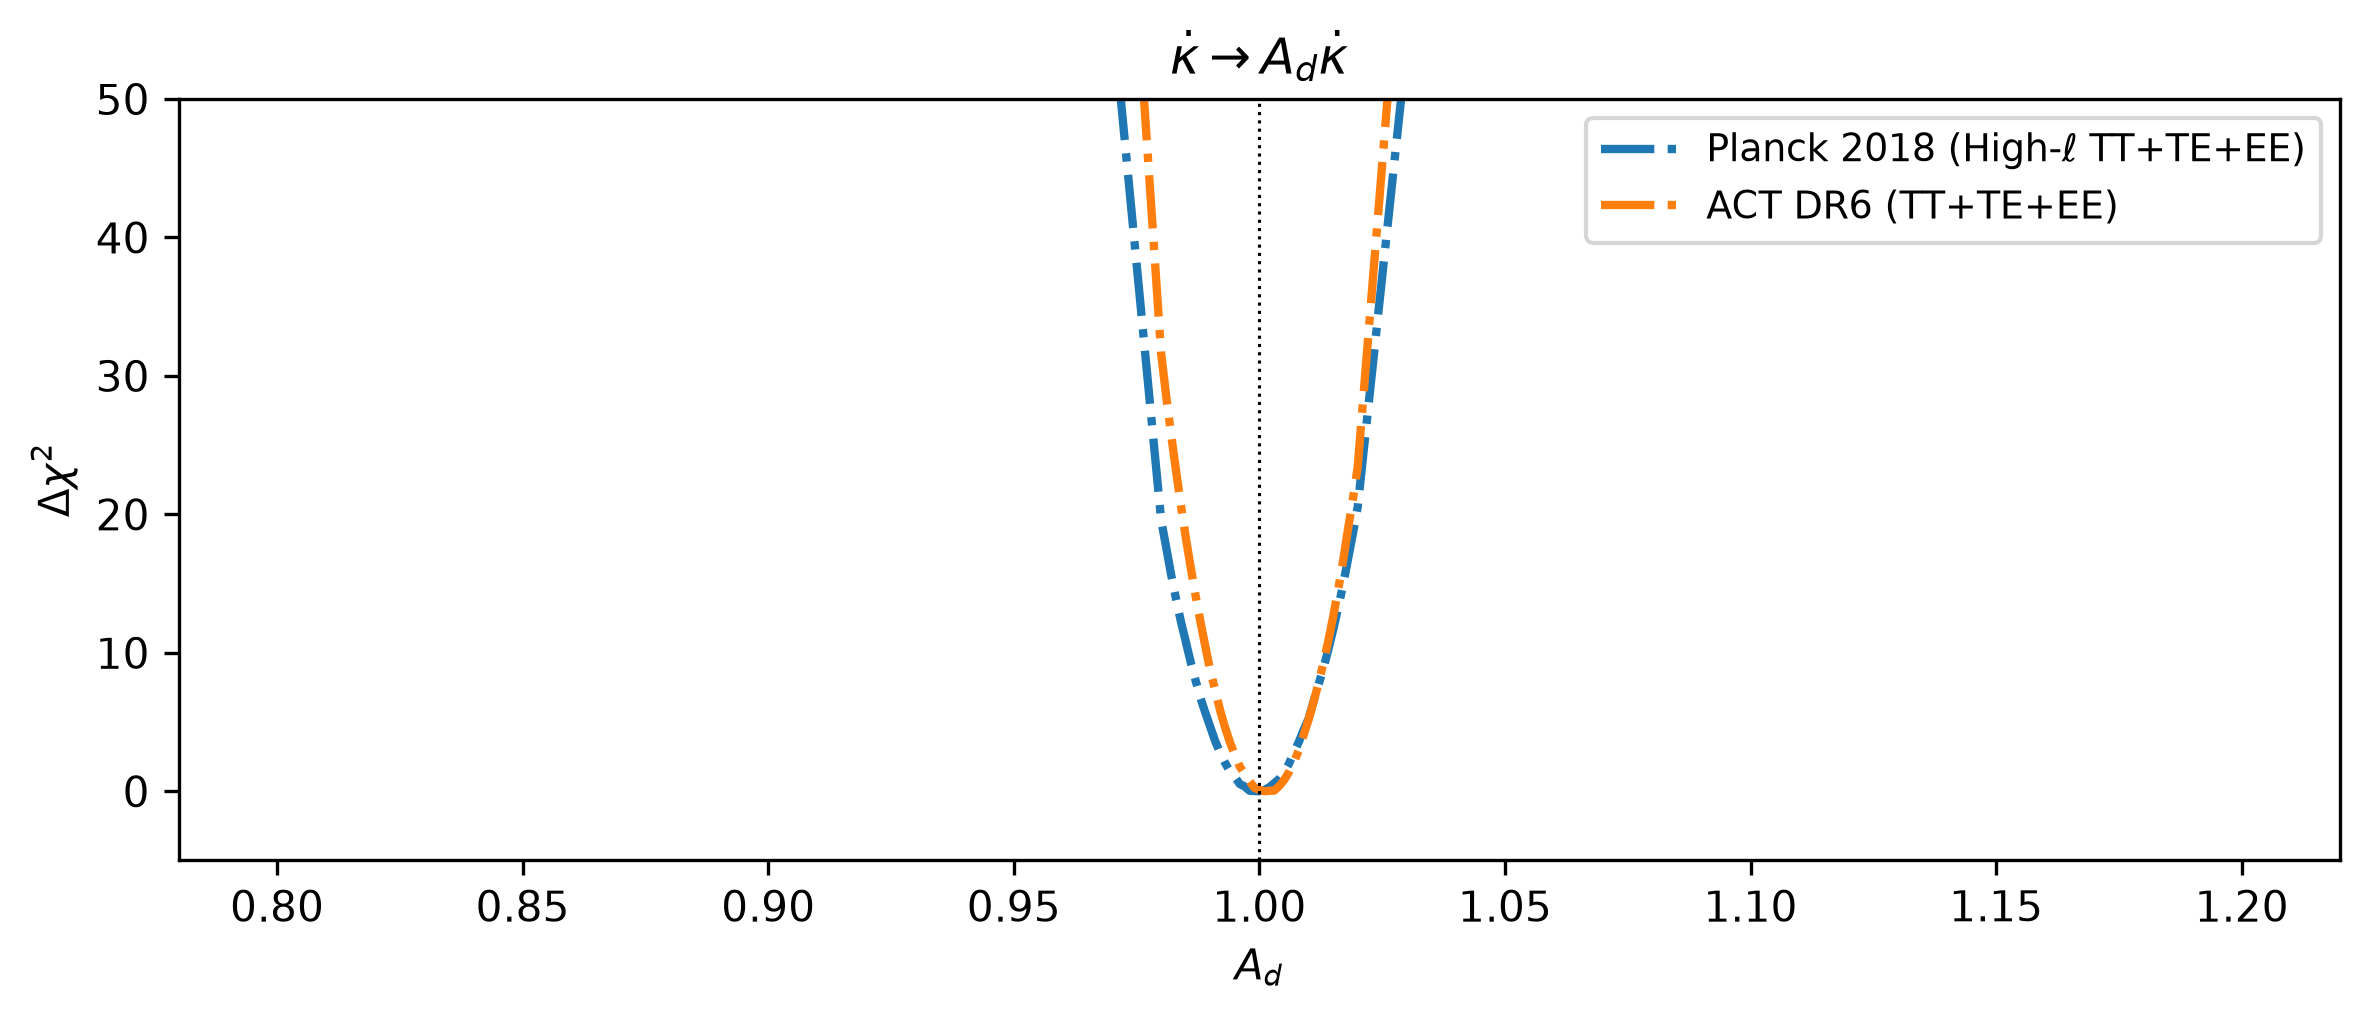

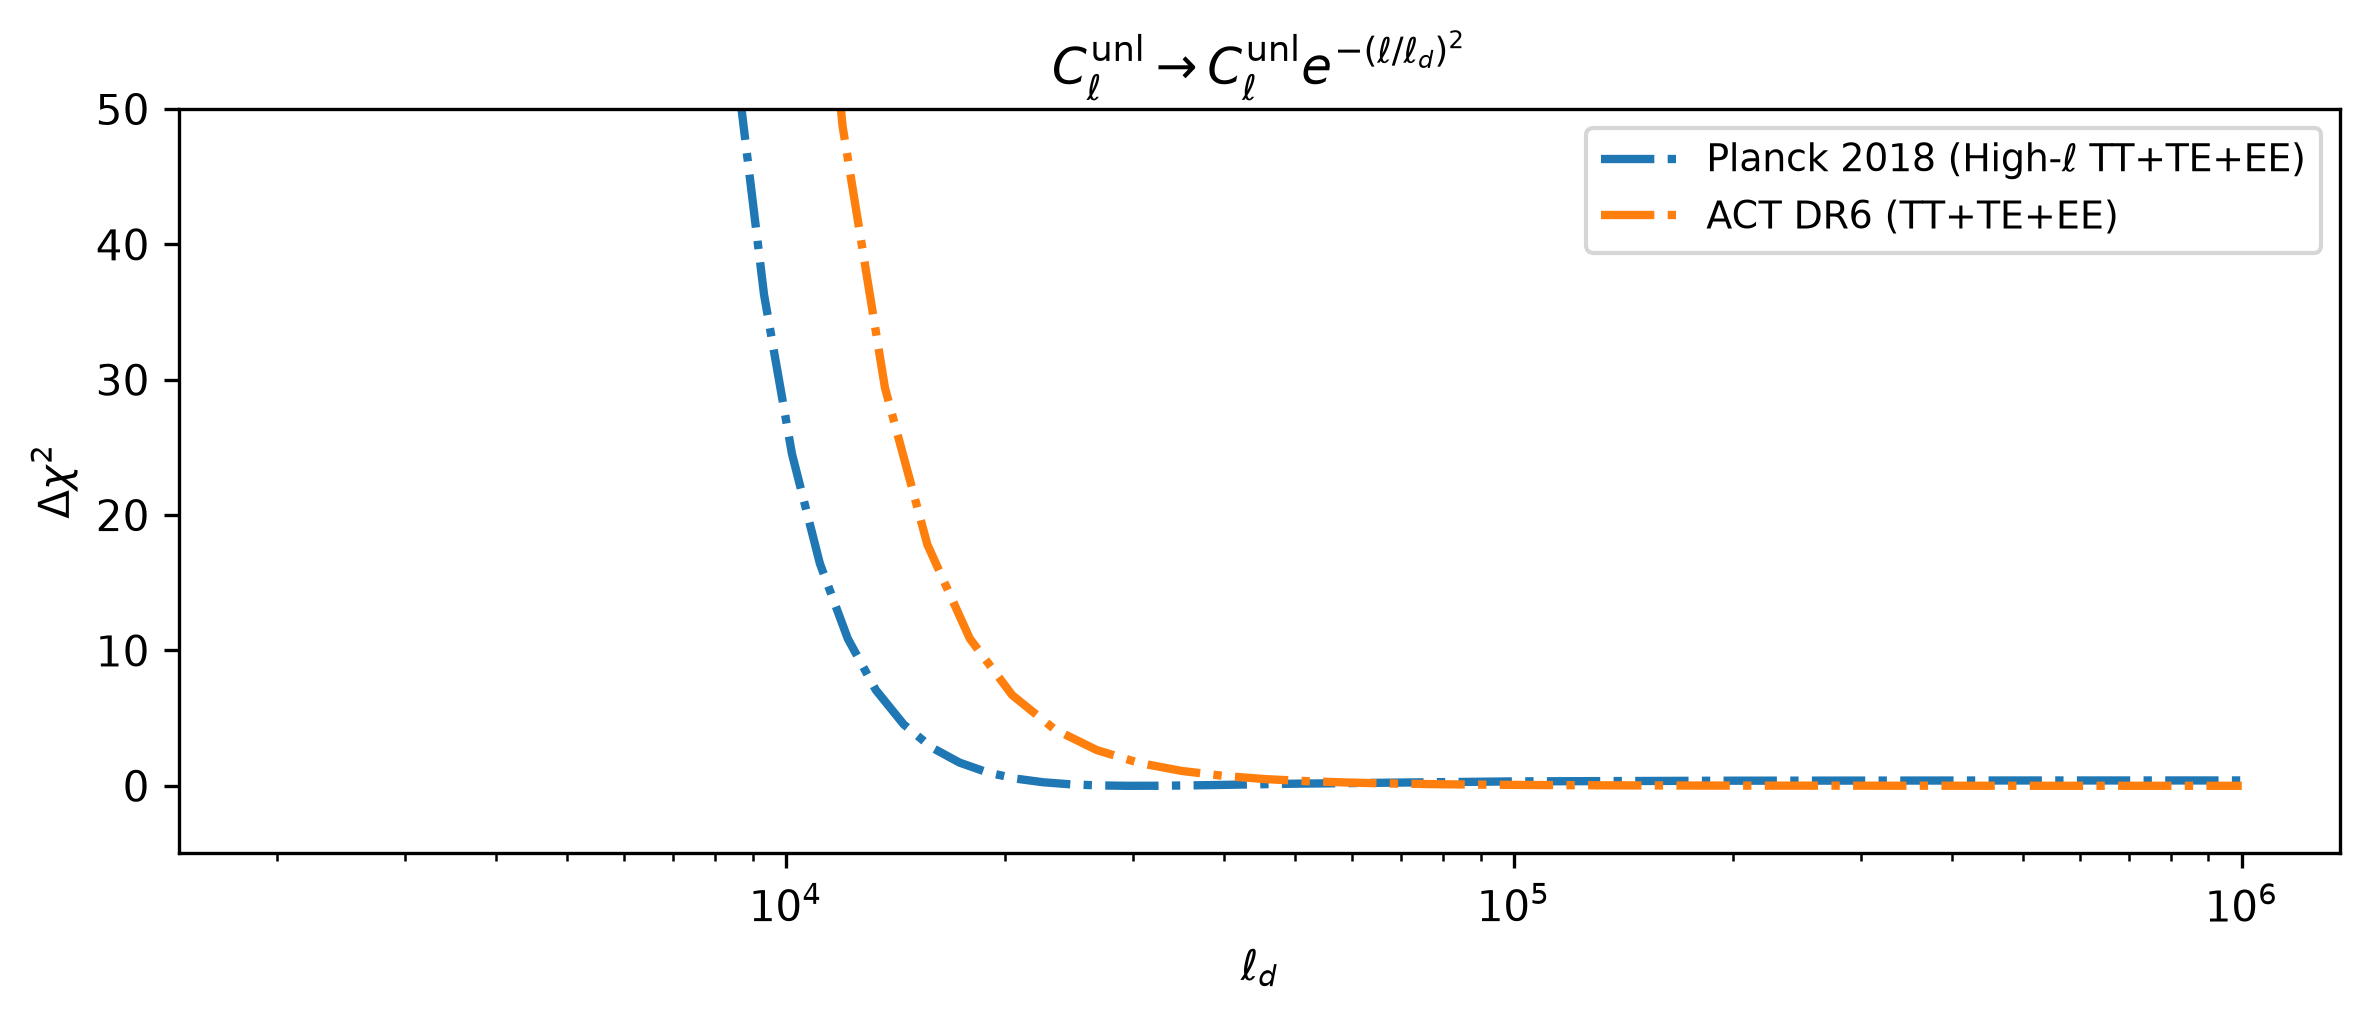

In [23]:
# --- TT+TE+EE likelihood: Planck + ACT ----------------
scan_dir = Path(".")
mode = "chi2"             # "L" = relative likelihood, "chi2" = Delta chi2

experiments = {
    "Planck": {
        "prefix": "Planck",
        "color": "tab:blue",
        "label": r"Planck 2018 (High-$\ell$ TT+TE+EE)",
    },
    "ACT": {
        "prefix": "ACT",
        "color": "tab:orange",
        "label": "ACT DR6 (TT+TE+EE)",
    },
}

def load_scan(fname):
    data = np.loadtxt(scan_dir / fname)
    data = data[np.argsort(data[:, 0])]
    chi2 = data[:, 1:]
    dchi2 = chi2 - chi2.min(axis=0)
    y = np.exp(-0.5 * dchi2) if mode == "L" else dchi2
    return data[:, 0], y[:, 0], y[:, 1:]


for suffix, lcdm_value, xlabel, logx in [
    ("_scan_A_d.txt",   1.0, r"$A_d$",    False),
    ("_scan_ell_d.txt", 0.0, r"$\ell_d$", True),
]:

    fig, ax = plt.subplots(figsize=(8, 3.5), dpi=300)

    for exp_name, exp in experiments.items():

        x, y_tot, y_like = load_scan(exp["prefix"] + suffix)

        if logx:
            keep = x > 0
            x, y_tot, y_like = x[keep], y_tot[keep], y_like[keep]

        # Planck: High-l TT+TE+EE is the 3rd likelihood column
        if exp_name == "Planck":
            y = y_like[:, 2]

        # ACT: chi2_total is TT+TE+EE
        elif exp_name == "ACT":
            y = y_tot

        ax.plot(
            x, y,
            color=exp["color"],
            linewidth=2.0,
            linestyle="-.",
            label=exp["label"],
        )

    if mode == "L":
        ax.set_ylabel(r"$\mathcal{L}/\mathcal{L}_{\rm max}$")
        ax.set_ylim(-0.05, 1.05)
    else:
        ax.set_ylabel(r"$\Delta\chi^2$")
        ax.set_ylim(-5, 50)

    ax.set_xlabel(xlabel)

    if logx:
        ax.set_xscale("log")
        ax.set_title(
            r"$C_\ell^\text{unl} \to C_\ell^\text{unl} e^{-(\ell/\ell_d)^2}$"
        )
    else:
        ax.axvline(
            lcdm_value,
            color="black",
            linewidth=0.75,
            linestyle=":"
        )
        ax.set_title(r"$\dot{\kappa}\to A_d\dot{\kappa}$")

    ax.legend(loc="upper left" if mode == "L" else "upper right", fontsize=9)

    plt.tight_layout()
    plt.show()

#### What's with the Planck A_d preference?

In [21]:
fid = {"omega_b": 0.02237, "omega_cdm": 0.1200, "H0": 67.36,
       "ln10^{10}A_s": 3.044, "n_s": 0.9649, "tau_reio": 0.0544,
       "N_ur": 2.0328, "N_ncdm": 1, "m_ncdm": 0.06,
       "output": "tCl,pCl,lCl", "lensing": "yes", "l_max_scalars": 4000}

def get_pp(A_d):
    print(A_d)
    c = Class()
    c.set({**fid, "thomson_rescaling": A_d})
    c.compute()
    cl = c.raw_cl(2500)
    c.struct_cleanup()
    L = cl["ell"][2:]
    return L, (L * (L + 1))**2 / (2 * np.pi) * cl["pp"][2:]   # [L(L+1)]^2 C_L^pp / 2pi

A_d_values = [0.8, 0.9, 0.95, 1.0, 1.05, 1.1, 1.2]
pp = {A: get_pp(A)[1] for A in A_d_values}
L = get_pp(1.0)[0]

# Numerical derivative d ln C_L^pp / d A_d at A_d = 1
h = 0.01
dlnpp_dAd = (get_pp(1 + h)[1] - get_pp(1 - h)[1]) / (2 * h) / pp[1.0]

# Planck 2018 lensing bandpowers (for the size of the error bars)
bp = np.loadtxt("../packages/data/planck_supp_data_and_covmats/lensing/2018/"
                "smicadx12_Dec5_ftl_mv2_ndclpp_p_teb_consext8_bandpowers.dat")
L_bp, frac_err = bp[:, 3], bp[:, 5] / bp[:, 4]

0.8
0.9
0.95
1.0
1.05
1.1
1.2
1.0
1.01
0.99


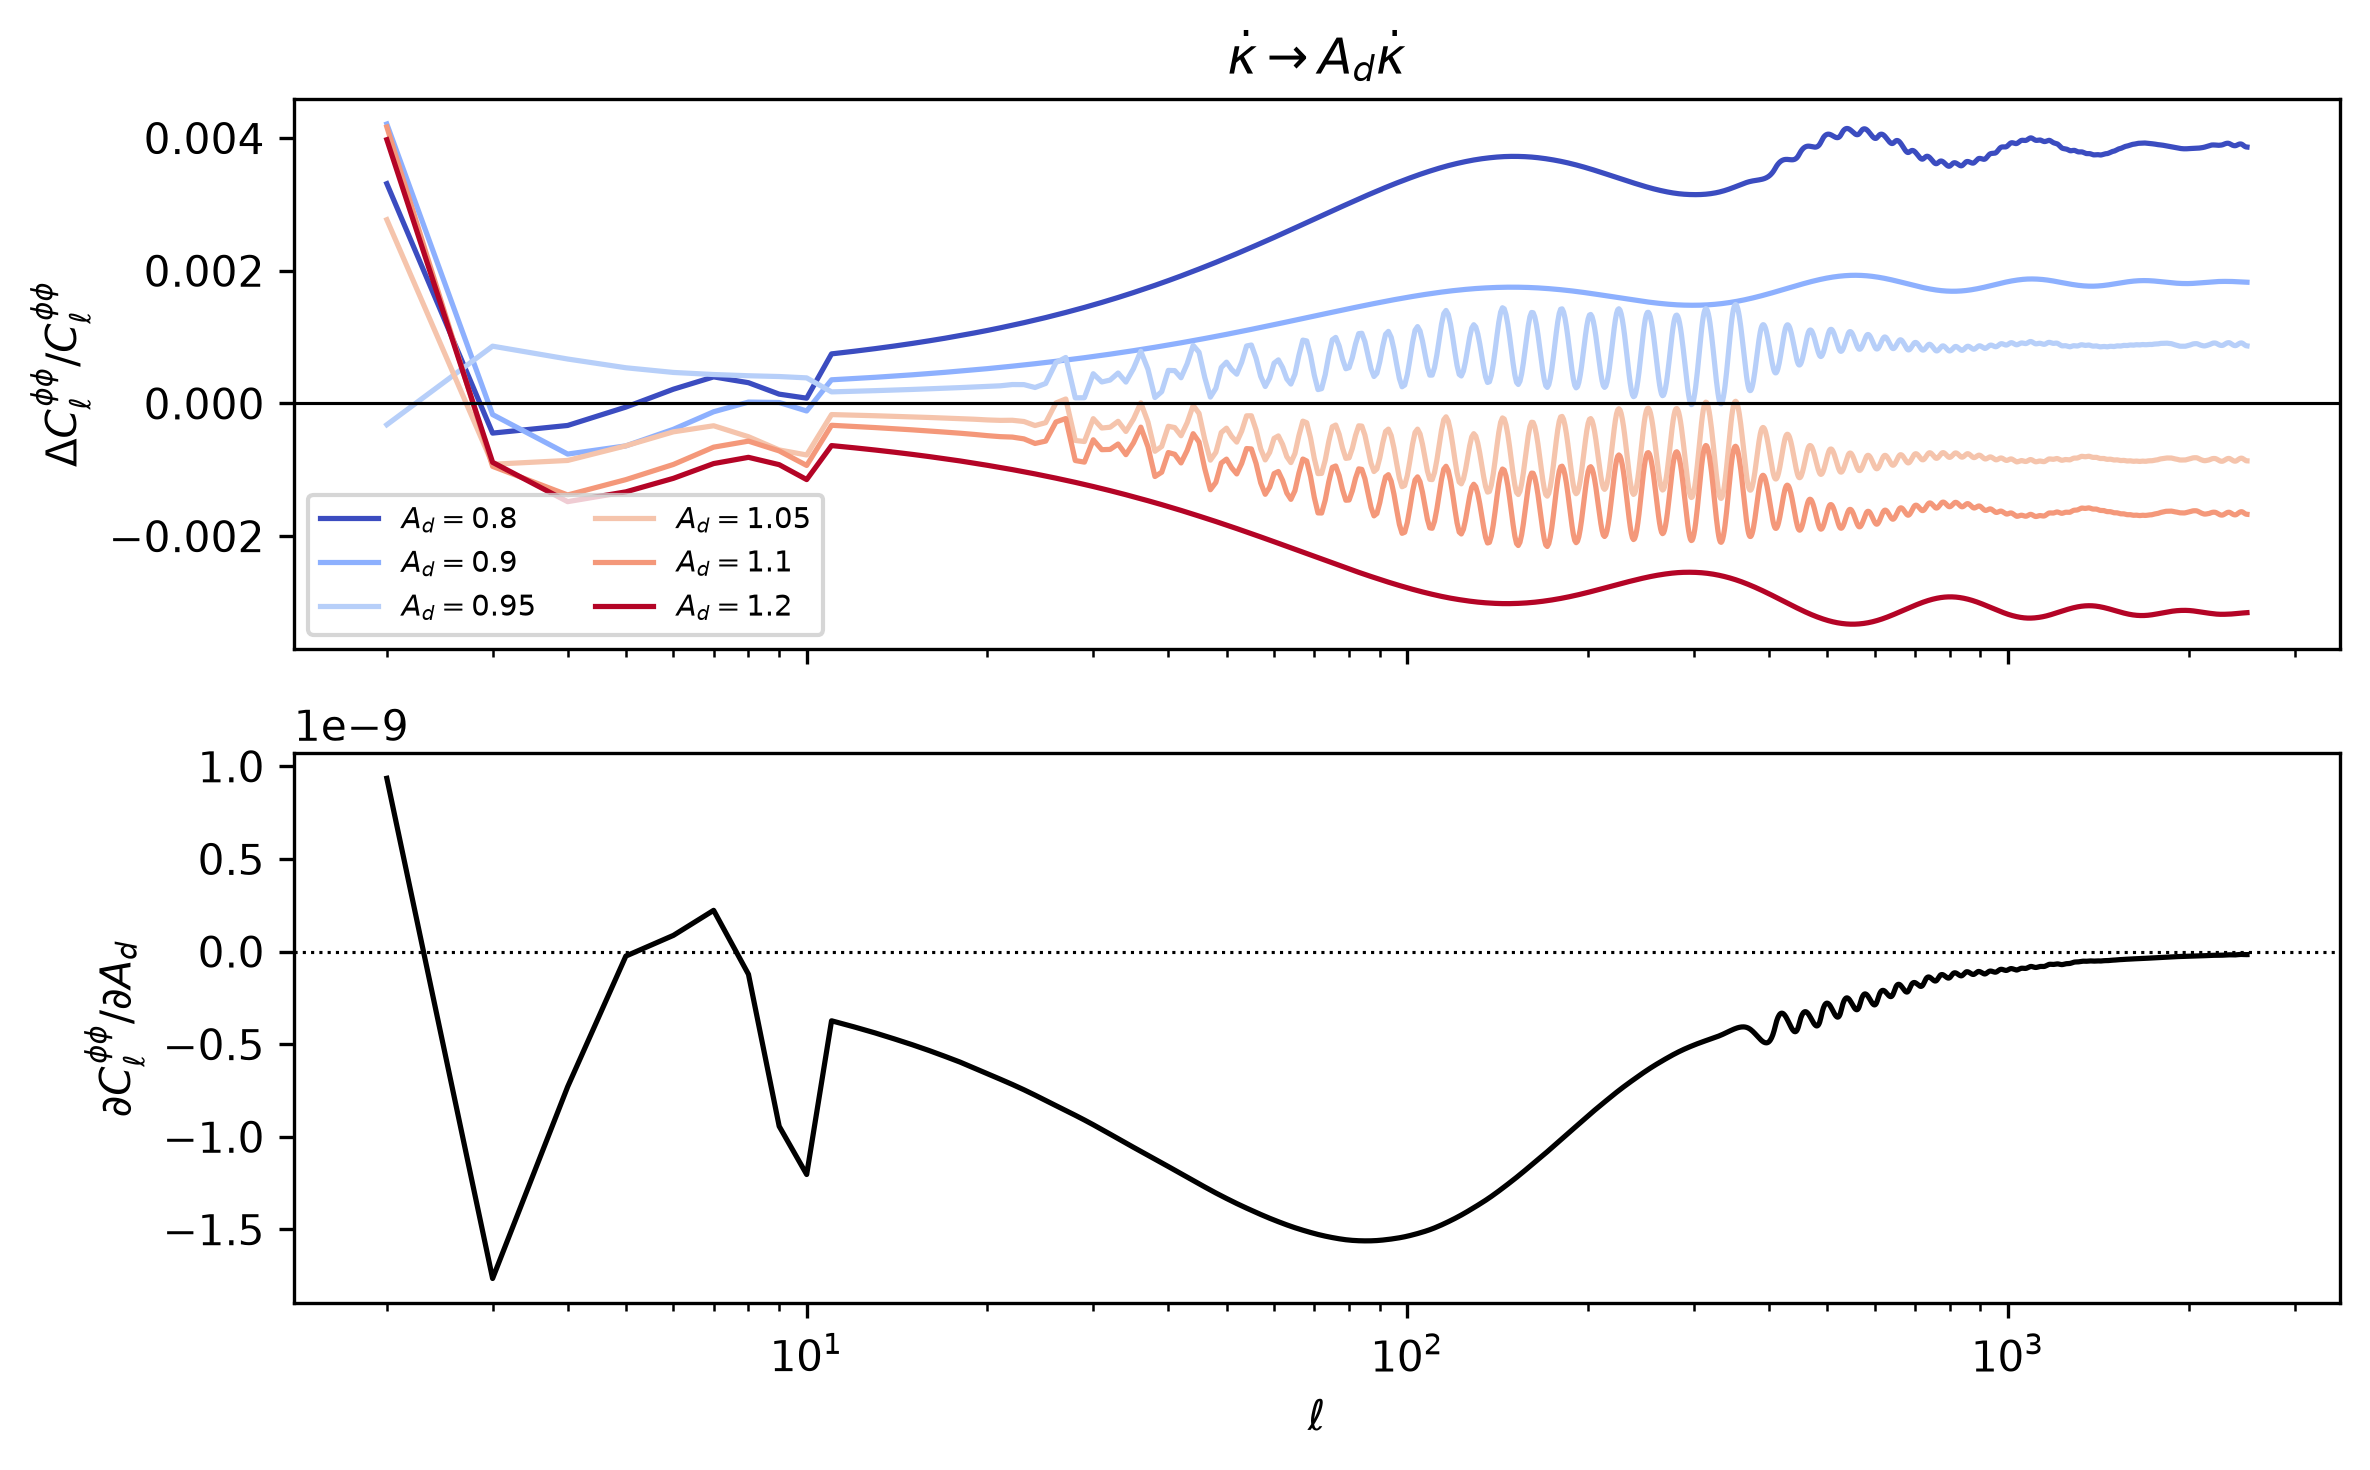

In [26]:
cmap = plt.cm.coolwarm
norm = TwoSlopeNorm(vmin=min(A_d_values), vcenter=1.0, vmax=max(A_d_values))
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 5), dpi=300, sharex=True)

for A in A_d_values:
    if np.isclose(A, 1.0):
        continue
    ax1.plot(L, pp[A] / pp[1.0] - 1, color=cmap(norm(A)),
             linewidth=1.25, label=rf"$A_d = {A:g}$")
#ax1.errorbar(L_bp, np.zeros_like(L_bp), yerr=frac_err, fmt="o", color="gray",
#             markersize=2.5, capsize=2, label="Planck 2018 lensing errors")
ax1.axhline(0, color="black", linewidth=0.75)
ax1.set_ylabel(r"$\Delta C_\ell^{\phi\phi} / C_\ell^{\phi\phi}$")
ax1.legend(fontsize=7, ncol=2)

#ax2.plot(L, dlnpp_dAd, color="black", linewidth=1.25)
#ax2.set_ylabel(r"$\partial \ln C_L^{\phi\phi} / \partial A_d$")
ax2.plot(L, dlnpp_dAd * pp[1.0], color="black", linewidth=1.25)
ax2.set_ylabel(r"$\partial C_\ell^{\phi\phi} / \partial A_d$")
ax2.axhline(0, color="black", linewidth=0.75, linestyle=":")
ax2.set_xlabel(r"$\ell$")
ax2.set_xscale("log")
ax1.set_title(r"$\dot{\kappa}\to A_d\dot{\kappa}$")
plt.tight_layout()
plt.show()

#### What's with the Planck ell_d preference?

In [16]:
from cobaya.model import get_model

plik_name = "planck_2018_highl_plik.TTTEEE_lite_native"
model = get_model({
    "packages_path": "../packages",
    "theory": {"classy": {"path": "global",
                          "extra_args": {"N_ur": 2.0328, "N_ncdm": 1, "m_ncdm": 0.06}}},
    "likelihood": {plik_name: None},
    "params": {"omega_b": 0.02237, "omega_cdm": 0.1200, "H0": 67.36,
               "ln10^{10}A_s": 3.044, "n_s": 0.9649, "tau_reio": 0.0544,
               "A_planck": 1.0,
               "phenomenological_damping_tail": {"prior": {"min": 0., "max": 1e6}}},
})
plik = model.likelihood[plik_name]

def get_dl(ell_d):
    """D_ell = l(l+1)C_l/2pi in muK^2, indexed by ell."""
    model.logposterior({"phenomenological_damping_tail": ell_d})
    cls = model.provider.get_Cl(ell_factor=True)
    return {s: cls[s].copy() for s in ["tt", "te", "ee"]}

[classy] `classy` module loaded successfully from /insomnia001/home/ja4020/envs/ange_cosmology/lib/python3.11/site-packages/classy


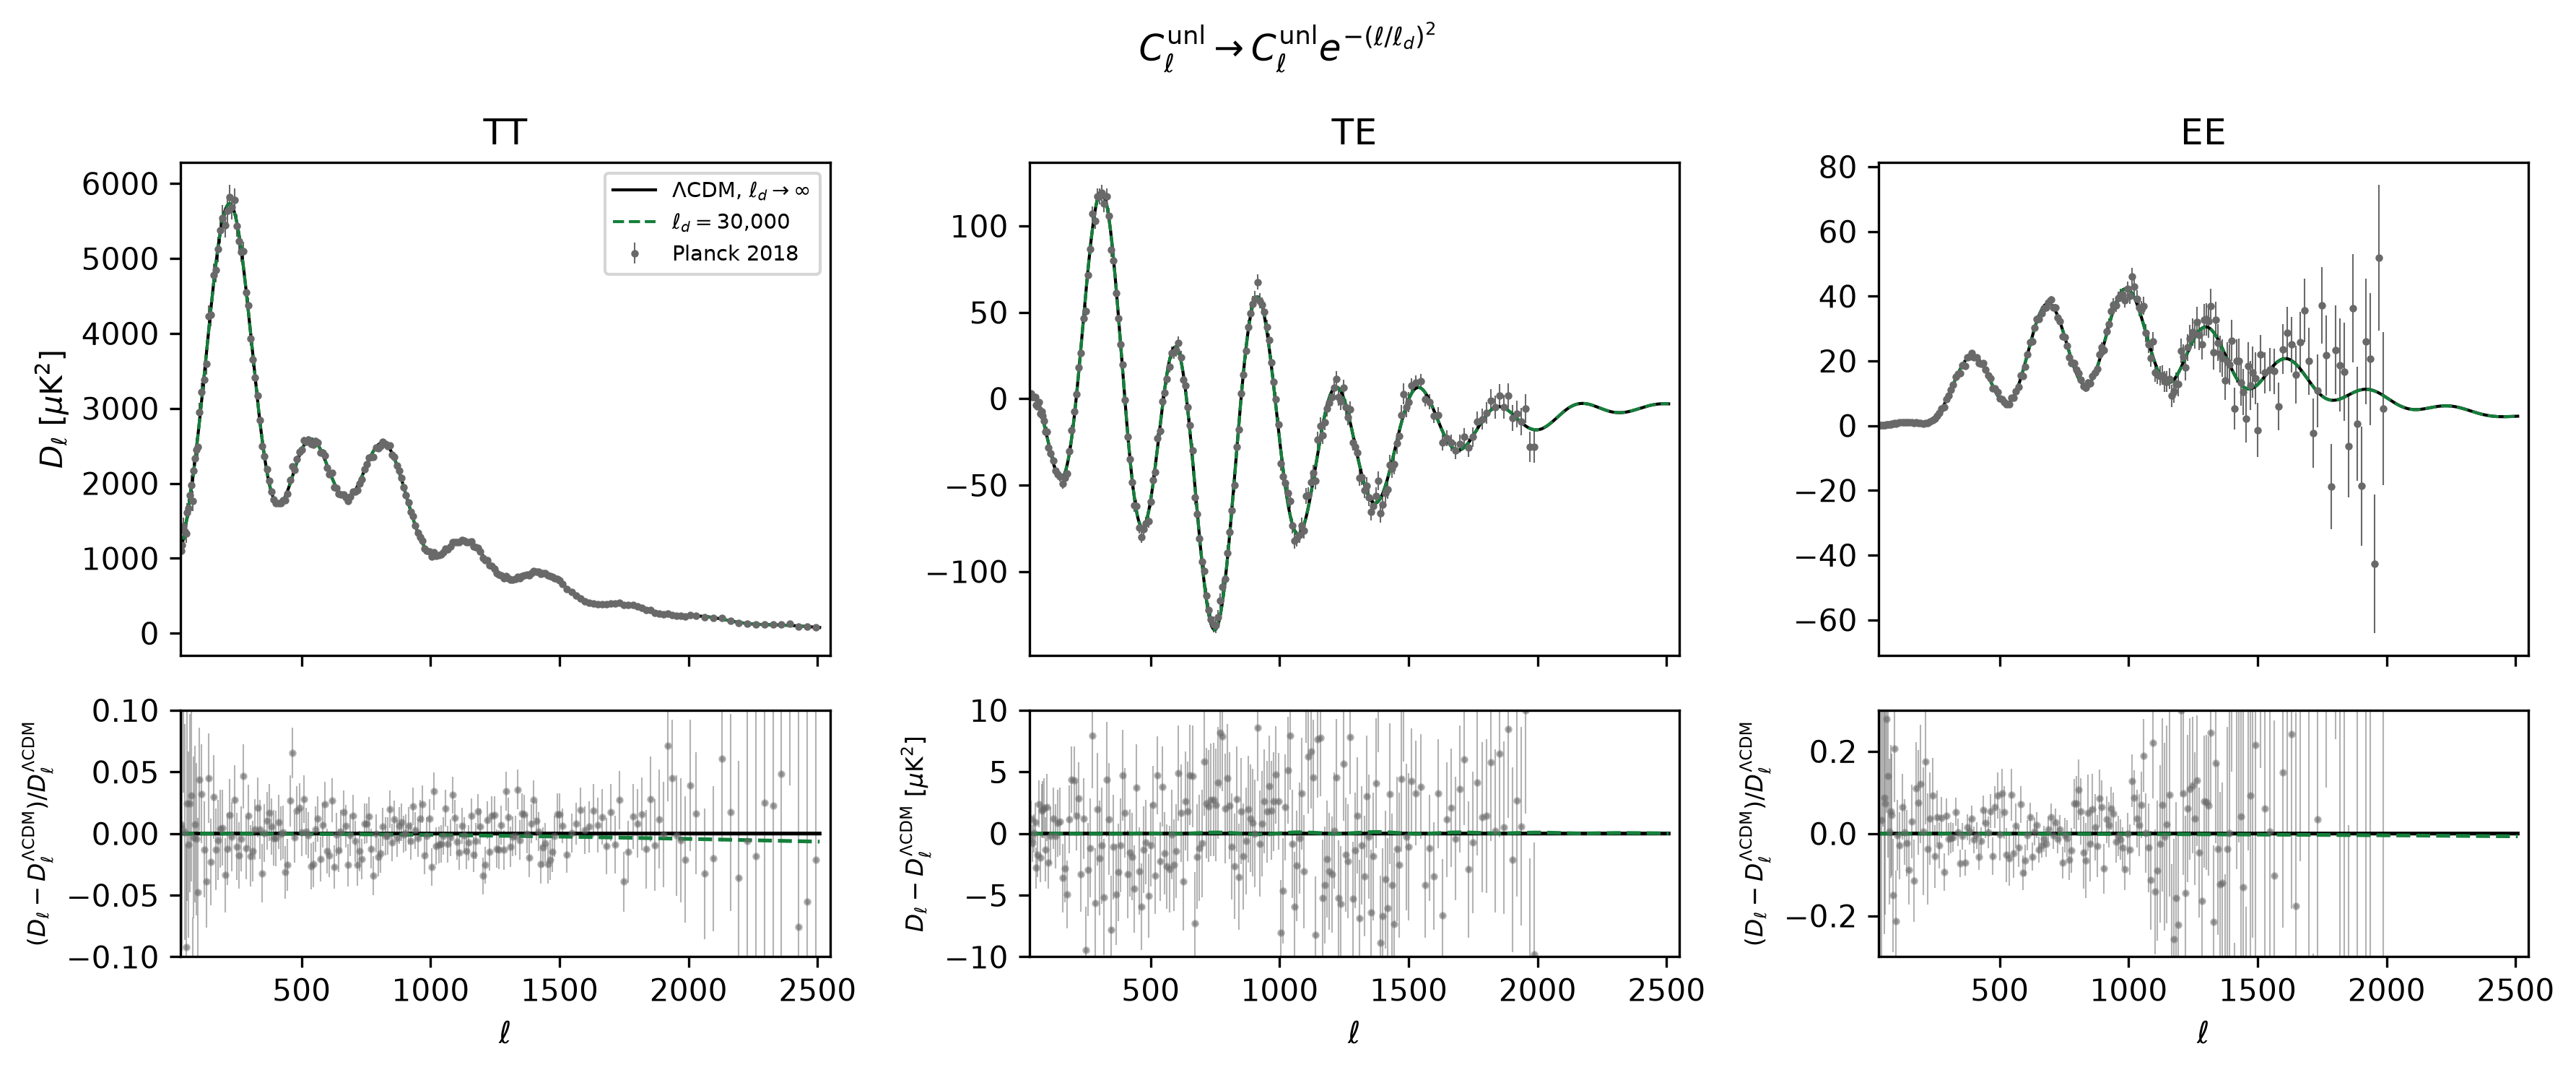

In [32]:
models = {
    r"$\Lambda$CDM, $\ell_d\to\infty$":         (get_dl(0.),     "black",              "-"),
    r"$\ell_d = 30{,}000$":  (get_dl(30000.), plt.cm.Greens(0.8),   "--"),
}
lcdm = models[r"$\Lambda$CDM, $\ell_d\to\infty$"][0]
ell = np.arange(len(lcdm["tt"]))

fig, axes = plt.subplots(2, 3, figsize=(12, 5), dpi=300, sharex="col",
                         gridspec_kw={"height_ratios": [2, 1]})

for col, spec in enumerate(["tt", "te", "ee"]):
    ax1, ax2 = axes[0, col], axes[1, col]

    # Planck data points: bin centres, measured D_ell, and 1-sigma errors
    l_data = plik.lav[:len(plik.bandpowers[spec])]
    data = plik.bandpowers[spec]
    err = plik.errors[spec]

    # Top: data and models
    ax1.errorbar(l_data, data, yerr=err, fmt="o", color="dimgray", markersize=1.5,
                 elinewidth=0.5, label="Planck 2018")
    for label, (dl, color, ls) in models.items():
        ax1.plot(ell, dl[spec], color=color, linestyle=ls, linewidth=1.0, label=label)
    ax1.set_title(spec.upper())
    ax1.set_xlim(30, 2550)

    # Bottom: everything minus LCDM.
    # TT and EE: as a fraction of LCDM. TE crosses zero, so there we use muK^2.
    if spec == "te":
        denom = np.ones_like(lcdm[spec])
        ylabel = r"$D_\ell - D_\ell^{\Lambda\rm CDM}$ [$\mu$K$^2$]"
    else:
        denom = lcdm[spec]
        ylabel = r"$(D_\ell - D_\ell^{\Lambda\rm CDM}) / D_\ell^{\Lambda\rm CDM}$"

    ax2.errorbar(l_data, (data - lcdm[spec][l_data]) / denom[l_data],
                 yerr=err / denom[l_data], fmt="o", color="dimgray", markersize=1.5,
                 elinewidth=0.5, alpha=0.5)
    for label, (dl, color, ls) in models.items():
        ax2.plot(ell[2:], (dl[spec][2:] - lcdm[spec][2:]) / denom[2:],
                 color=color, linestyle=ls, linewidth=1.25)
    ax2.set_ylabel(ylabel, fontsize=8)
    ax2.set_xlabel(r"$\ell$")

axes[1, 0].set_ylim(-0.1, 0.1)
axes[1, 1].set_ylim(-10, 10)
axes[1, 2].set_ylim(-0.3, 0.3)
axes[0, 0].set_ylabel(r"$D_\ell$ [$\mu$K$^2$]")
axes[0, 0].legend(fontsize=7)
fig.suptitle(r"$C_\ell^\text{unl} \to C_\ell^\text{unl} e^{-(\ell/\ell_d)^2}$")
plt.tight_layout()
plt.show()

### MCMCs

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import os
from getdist import loadMCSamples, plots

chains/Planck_MCMC_A_d_noLensing.1.txt
chains/Planck_MCMC_A_d_noLensing.2.txt
chains/Planck_MCMC_A_d_noLensing.3.txt
chains/Planck_MCMC_A_d_noLensing.4.txt
Removed 0.3 as burn in
chains/ACT_MCMC_A_d.1.txt
chains/ACT_MCMC_A_d.2.txt
chains/ACT_MCMC_A_d.3.txt
chains/ACT_MCMC_A_d.4.txt
Removed 0.3 as burn in


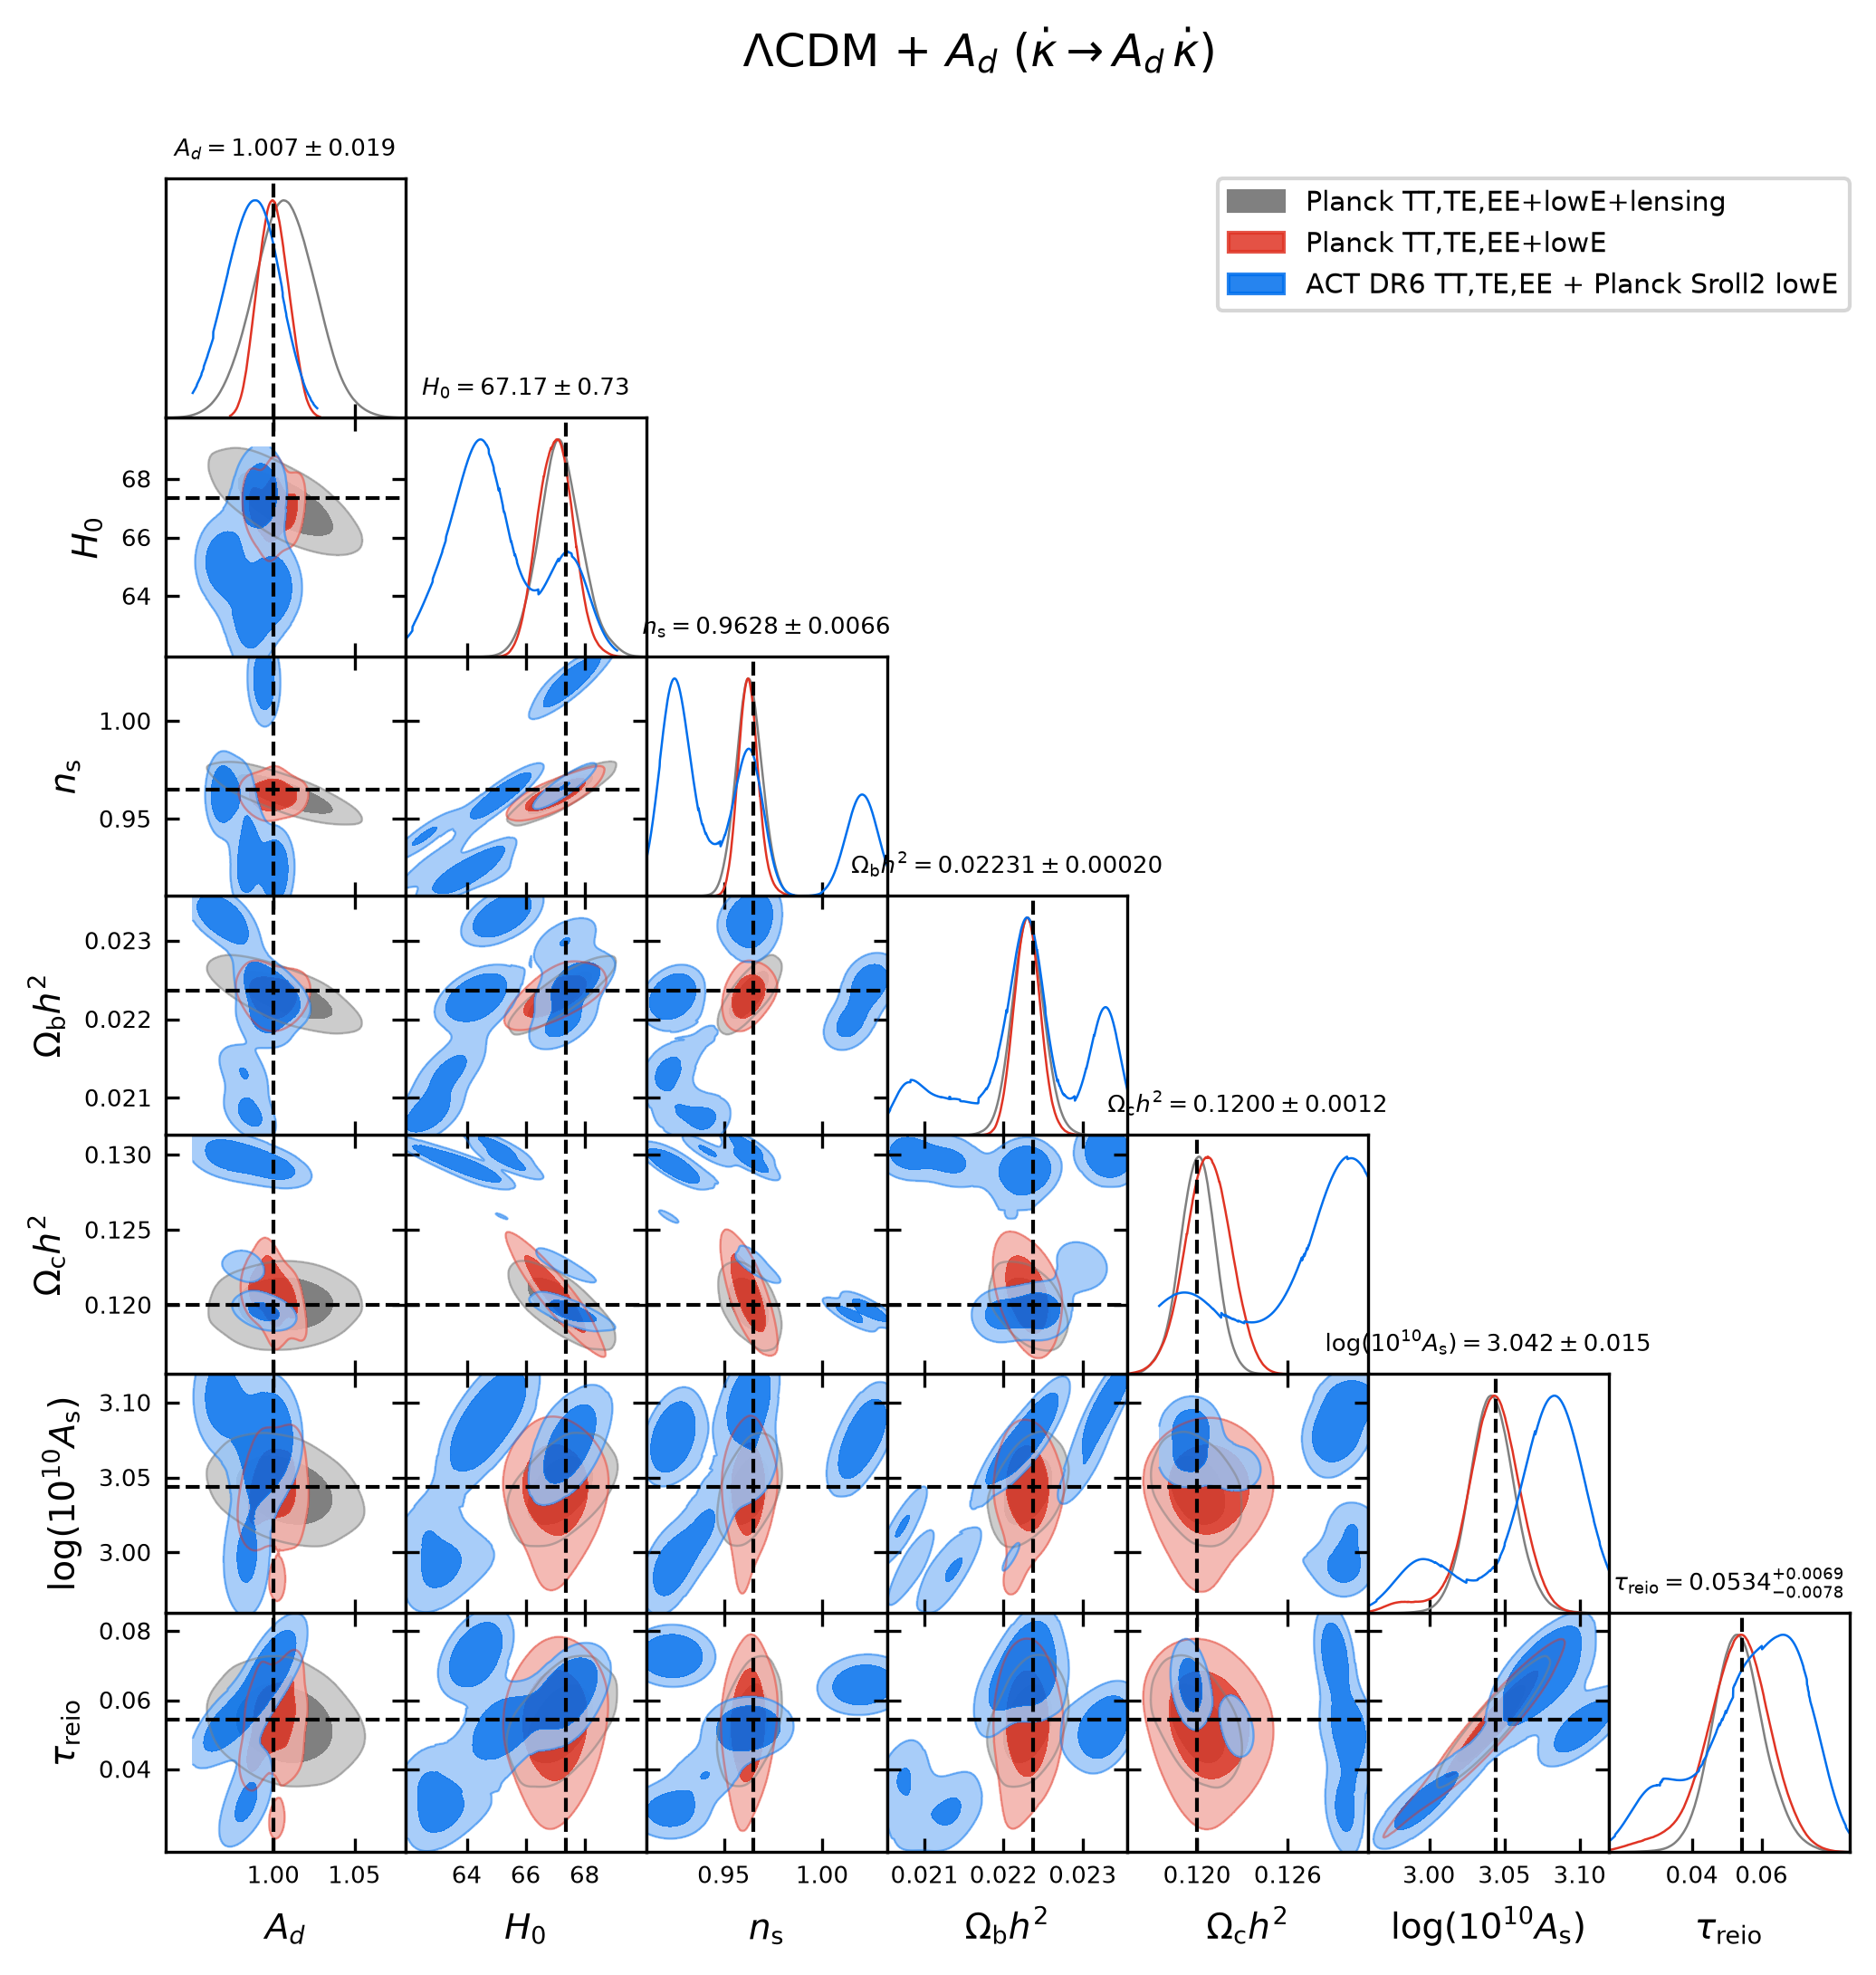


Planck TT,TE,EE+lowE+lensing
   A_d = 1.007\pm 0.019
   H_0 = 67.17\pm 0.73
   n_\mathrm{s} = 0.9628\pm 0.0066
   \Omega_\mathrm{b} h^2 = 0.02231\pm 0.00020
   \Omega_\mathrm{c} h^2 = 0.1200\pm 0.0012
   \log(10^{10} A_\mathrm{s}) = 3.042\pm 0.015
   \tau_\mathrm{reio} = 0.0534^{+0.0069}_{-0.0078}
   corr(A_d, H0) = -0.69

Planck TT,TE,EE+lowE
   A_d = 0.9997\pm 0.0088
   H_0 = 67.00\pm 0.59
   n_\mathrm{s} = 0.9624^{+0.0045}_{-0.0051}
   \Omega_\mathrm{b} h^2 = 0.02230\pm 0.00015
   \Omega_\mathrm{c} h^2 = 0.1207\pm 0.0015
   \log(10^{10} A_\mathrm{s}) = 3.041^{+0.020}_{-0.015}
   \tau_\mathrm{reio} = 0.0527^{+0.010}_{-0.0083}
   corr(A_d, H0) = -0.004

ACT DR6 TT,TE,EE + Planck Sroll2 lowE
   A_d = 0.987\pm 0.013
   H_0 = 65.1^{+2.6}_{-2.1}
   n_\mathrm{s} = 0.958^{+0.067}_{-0.043}
   \Omega_\mathrm{b} h^2 = 0.0223^{+0.0012}_{-0.00047}
   \Omega_\mathrm{c} h^2 > 0.129
   \log(10^{10} A_\mathrm{s}) = 3.066^{+0.046}_{-0.013}
   \tau_\mathrm{reio} = 0.0565^{+0.020}_{-0.0096}
   corr(A_

In [12]:
experiments = {
    "chains/Planck_MCMC_A_d"           : "Planck TT,TE,EE+lowE+lensing",
    "chains/Planck_MCMC_A_d_noLensing" : "Planck TT,TE,EE+lowE",
    "chains/ACT_MCMC_A_d"              : "ACT DR6 TT,TE,EE + Planck Sroll2 lowE",
}

params = ["A_d", "H0", "n_s", "omega_b", "omega_cdm", "logA", "tau_reio"]

# Dashed lines: A_d = 1 (standard scattering rate) and Planck 2018
# TT,TE,EE+lowE+lensing LCDM posterior means (Planck 2018 VI, Table 2)
reference = {"A_d": 1.0, "H0": 67.36, "n_s": 0.9649, "omega_b": 0.02237,
             "omega_cdm": 0.1200, "logA": 3.044, "tau_reio": 0.0544}

samples, labels = [], []
for root, label in experiments.items():
    if os.path.exists(root + ".1.txt"):
        samples.append(loadMCSamples(root, settings={"ignore_rows": 0.3}))  # drop first 30% as burn-in
        labels.append(label)
    else:
        print(f"Skipping {label}: no chains at {root}")

g = plots.get_subplot_plotter(width_inch=8)
g.triangle_plot(samples, params, filled=True,
                legend_labels=labels, legend_loc="upper right",
                markers=reference, marker_args={"color": "black", "ls": "--", "lw": 1},
                title_limit=1)          # 68% limits of the FIRST run above each diagonal panel
plt.suptitle(r"$\Lambda$CDM + $A_d$ ($\dot\kappa \to A_d\,\dot\kappa$)", y=0.95)
plt.gcf().set_dpi(300)
plt.show()

# Numbers for each run
for label, s in zip(labels, samples):
    print(f"\n{label}")
    for p in params:
        print("  ", s.getInlineLatex(p, limit=1))
    print("   corr(A_d, H0) =", round(s.corr(["A_d", "H0"])[0, 1], 3))

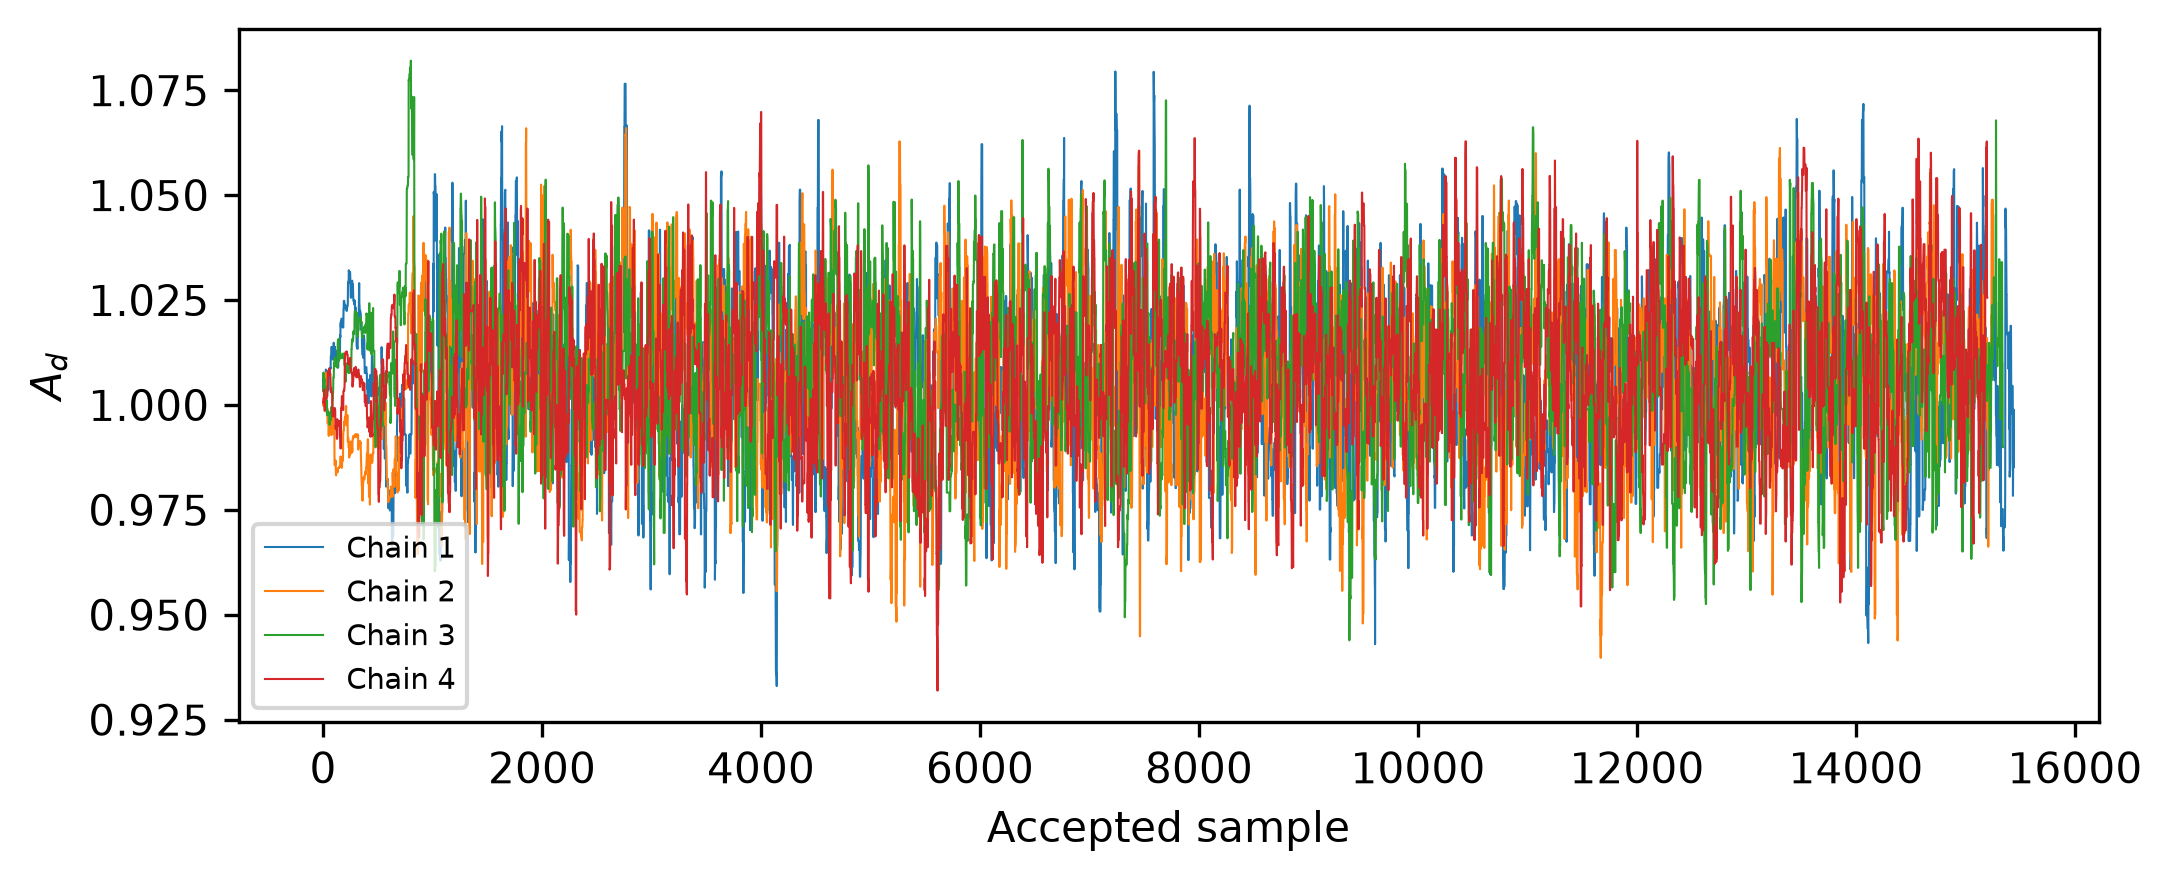

In [6]:
fig, ax = plt.subplots(figsize=(8, 3), dpi=300)
for i in range(1, 5):
    d = np.loadtxt(f"chains/Planck_MCMC_A_d.{i}.txt")
    ax.plot(d[:, 2], lw=0.5, label=f"Chain {i}")   # column 2 = A_d (columns 0, 1 are weight, -log posterior)
ax.set_xlabel("Accepted sample"); ax.set_ylabel(r"$A_d$"); ax.legend(fontsize=7)
plt.show()